In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple, Mapping, Optional, Iterable, List, Union
import os, re, math, gzip, pickle, tempfile, platform, sys, json
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from matplotlib.dates import date2num
import treeswift
import baltic as bt
from collections import defaultdict
import joblib
from utils import *

# set helvetica neue
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Helvetica Neue'


# Phylogeny

In [2]:
b313_tree_path = '../analysis/b313/beast_bird_cattle_combined/PA-HA-NA-MP/combined/combined.resampled.hipstr.tree'

tt = treeswift.read_tree_nexus(b313_tree_path)['TREE1']
b313_ancestors = '''A/peregrine_falcon/California/24-005915-001/2024|H5N1|USA-CA|2024-02-14|avian|B3.13
A/Canada_goose/Wyoming/24-003692-001/2024|H5N1|USA-WY|2024-01-25|avian|B3.13
A/skunk/New_Mexico/24-006483-001/2024|H5N1|USA-NM|2024-02-23|other_mammal|B3.13
A/goose/Colorado/23-038138-001/2023|H5N1|USA-CO|2023-11-26|avian|B3.13'''.split('\n')

def b313_and_immediateAncestors_subtree(tree, steps_up=5, max_date='2024-06-01', b313_ancestors=b313_ancestors):
    leaves = [n.label for n in tree.traverse_leaves()]
    b313_leaves = [l for l in leaves if 'B3.13' in l]
    b313_outbreak_leaves = [l for l in b313_leaves if not any(anc in l for anc in b313_ancestors)]
    b313_mrca = tree.mrca(b313_leaves)

    ancestor = b313_mrca
    while steps_up > 0 and ancestor.parent is not None:
        ancestor = ancestor.parent
        steps_up -= 1
    
    subtree = tree.extract_subtree(ancestor)
    subtree_leaves = [n for n in subtree.traverse_leaves() if n.label is not None]
    subtree_leaves_subset = [n.label for n in subtree_leaves if (((n.label.split('|')[-3] <= max_date) and ('B3.13' in n.label)) or ('B3.13' not in n.label))]
    
    pruned_subtree = tree.extract_tree_with(labels=subtree_leaves_subset)
    return pruned_subtree, b313_leaves, b313_outbreak_leaves


tt_sub, b313_leaves, b313_outbreak_leaves = b313_and_immediateAncestors_subtree(tt, steps_up=3, max_date='2024-05-01')
tt_sub_path = b313_tree_path.replace('.tree', '.b313_and_immediateAncestors.subtree.nexus')
tt_sub.root.edge_length = 0
tt_sub.write_tree_nexus(tt_sub_path)

/opt/miniconda3/envs/moo_flu_fixed/lib/python3.13/site-packages/treeswift/Tree.py:1185: UserWarning: Deleting a node with label/attributes in suppress_unifurcations: <treeswift.Node.Node object at 0x16dd20c90> {'children': [<treeswift.Node.Node object at 0x16dd20d00>], 'parent': None, 'label': None, 'edge_length': None, 'node_params': '&posterior=1.0,rate=3.342050417902912,rate_median=3.333312612708876,rate_95%_HPD={3.2468417239526666,3.44267407024769},rate_range={3.2254653154887354,3.6539130534315434},rate_signDistribution={0.0,1.0},length=0.0,height_mean=3.342050417902912,height_median=3.333312612708876,height_95%_HPD={3.2468417239526666,3.44267407024769},height_range={3.2254653154887354,3.6539130534315434}'}
  warn("Deleting a node with label/attributes in suppress_unifurcations: %s" % tmp_s)
/opt/miniconda3/envs/moo_flu_fixed/lib/python3.13/site-packages/treeswift/Tree.py:1185: UserWarning: Deleting a node with label/attributes in suppress_unifurcations: <treeswift.Node.Node object

# tMRCAs

In [ ]:
def assign_heights_to_nodes(tree, max_date=toYearFraction('2024-12-26')):
    for node in tree.traverse_preorder():
        if node.is_root():
            node.height = tree.height()
            node.date = toDatestring(max_date - node.height)
            continue
        node.height = node.parent.height - node.edge_length
        node.date = toDatestring(max_date - node.height)
        
        
trees_path = '../analysis/b313/beast_bird_cattle_combined/PA-HA-NA-MP/combined/combined.resampled.trees'
trees = treeswift.read_tree_nexus(trees_path)

t = trees[list(trees.keys())[-1]]
max_date = '2020-01-01'
for k in t.traverse_leaves():
    date_str = k.label.split('|')[-3]
    if date_str > max_date:
        max_date = date_str

tmrcas = []
for k in trees:
    if 'STATE' not in k:
        continue
    t = trees[k]
    assign_heights_to_nodes(t, max_date=toYearFraction(max_date))
    tmrca_outbreak = t.mrca(b313_outbreak_leaves)
    tmrca_b313 = t.mrca(b313_leaves)
    tmrcas.append((tmrca_outbreak.date, tmrca_outbreak.parent.date, tmrca_b313.date, tmrca_b313.parent.date))

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10524e270>>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/moo_flu_fixed/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


In [ ]:
tmrcas_df = pd.DataFrame(tmrcas, columns=['tmrca_outbreak', 'tpmrca_outbreak', 'tmrca_b313', 'tpmrca_b313'])
# apply toYearFraction to convert date strings to decimal years
for col in tmrcas_df.columns:
    tmrcas_df[col] = tmrcas_df[col].map(toYearFraction)


In [ ]:
def assign_absolute_times_from_root_heights(tree):
    """
    Given a baltic tree whose .height is measured from the root,
    infer a linear mapping

        absoluteTime = a + b * height

    using tip heights vs tip sampling dates from tip labels.

    Tip labels must contain at least one 'YYYY-MM-DD' token.
    """

    tip_heights = []
    tip_dates = []

    for tip in tree.getExternal():
        parts = tip.name.split('|')
        date_str = None
        for p in parts:
            # simple YYYY-MM-DD heuristic
            if len(p) == 10 and p[4] == '-' and p[7] == '-':
                date_str = p
                break

        if date_str is None:
            continue

        try:
            dec_date = bt.decimalDate(date_str)
        except Exception:
            continue

        h = getattr(tip, "height", None)
        if h is None:
            continue

        tip_heights.append(float(h))
        tip_dates.append(float(dec_date))

    if len(tip_heights) < 2:
        raise ValueError(
            "Not enough tips with parsable dates to fit height→time mapping."
        )

    tip_heights = np.array(tip_heights)
    tip_dates = np.array(tip_dates)

    # Fit linear mapping: date ≈ a + b * height
    b, a = np.polyfit(tip_heights, tip_dates, 1)  # slope b, intercept a

    # Assign absoluteTime to all nodes
    for node in tree.Objects:
        h = getattr(node, "height", None)
        if h is None:
            raise ValueError("Node missing .height — cannot assign absoluteTime.")
        node.absoluteTime = a + b * float(h)

    # Store mostRecent as max tip absoluteTime
    tree.mostRecent = max(
        node.absoluteTime for node in tree.getExternal()
        if getattr(node, "absoluteTime", None) is not None
    )

    return tree


b313_taxa_subset = '''A/goose/Colorado/23-038138-001/2023|H5N1|USA-CO|2023-11-26|avian|B3.13
A/skunk/New_Mexico/24-006483-001/2024|H5N1|USA-NM|2024-02-23|other_mammal|B3.13
A/peregrine_falcon/California/24-005915-001/2024|H5N1|USA-CA|2024-02-14|avian|B3.13
A/Canada_goose/Wyoming/24-003692-001/2024|H5N1|USA-WY|2024-01-25|avian|B3.13
A/Texas/37/2024|H5N1|USA-TX|2024-03-28|human|B3.13
A/cattle/Texas/24-009110-023/2024|H5N1|USA-TX|2024-03-14|cattle|B3.13'''.strip().split('\n')
b313_outbreak_taxa_subset = b313_taxa_subset[4:]

b313_mrca = None
b313_outbreak_mrca = None

tt_sub = bt.loadNewick(tt_sub_path)
assign_absolute_times_from_root_heights(tt_sub)

# based on baltic's allTMRCAs(), modified to also store MRCA nodes
tip_names=[k.name for k in tt_sub.getExternal()]
mrcaMatrix={x:{y:None if x!=y else x for y in tip_names} for x in tip_names} ## pairwise matrix of tips; just use tip names on diagonal; rest will be nodes
tmrcaMatrix={x:{y:None if x!=y else 0.0 for y in tip_names} for x in tip_names} ## pairwise matrix of tips

for k in tt_sub.getInternal(): ## iterate over nodes
    all_children=list(k.leaves) ## fetch all descendant tips of node

    if all(c in all_children for c in b313_taxa_subset):
        if b313_mrca is None or k.absoluteTime > b313_mrca.absoluteTime:
            b313_mrca = k
    if all(c in all_children for c in b313_outbreak_taxa_subset):
        if b313_outbreak_mrca is None or k.absoluteTime > b313_outbreak_mrca.absoluteTime:
            b313_outbreak_mrca = k
    
    # for a,tipA in enumerate(all_children):
        # for tipB in all_children[a+1:]:
            # if tmrcaMatrix[tipA][tipB]==None or tmrcaMatrix[tipA][tipB]<=k.absoluteTime: ## if node's time is more recent than previous entry - set new TMRCA value for pair of tips
            #     mrcaMatrix[tipA][tipB]=k
            #     mrcaMatrix[tipB][tipA]=k
            #     tmrcaMatrix[tipA][tipB]=k.absoluteTime
            #     tmrcaMatrix[tipB][tipA]=k.absoluteTime

b313_mrca.absoluteTime, b313_outbreak_mrca.absoluteTime


def get_mrca(tree, taxa: List[str]):
    """
    Given a baltic tree and a list of tip names (taxa),
    return the MRCA node of those taxa, or None if not found.
    """
    mrca_node = None

    for k in tree.getInternal(): ## iterate over nodes
        all_children = list(k.leaves) ## fetch all descendant tips of node

        if all(c in all_children for c in taxa):
            if mrca_node is None or k.absoluteTime > mrca_node.absoluteTime:
                mrca_node = k

    return mrca_node

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_57397/3007038585.py:113: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


{<baltic.baltic.leaf object at 0x102982fd0>: 2, <baltic.baltic.leaf object at 0x316601e50>: 2, <baltic.baltic.leaf object at 0x316601f90>: 2, <baltic.baltic.leaf object at 0x316602030>: 2, <baltic.baltic.leaf object at 0x3166020d0>: 2, <baltic.baltic.leaf object at 0x31448bc50>: 2, <baltic.baltic.leaf object at 0x316602210>: 2, <baltic.baltic.leaf object at 0x3166022b0>: 2, <baltic.baltic.leaf object at 0x316602170>: 2, <baltic.baltic.leaf object at 0x316602350>: 2, <baltic.baltic.node object at 0x3ee3eefc0>: 1, <baltic.baltic.node object at 0x3ee3ef070>: 1, <baltic.baltic.node object at 0x3ee3ef330>: 1}
y min: -5.0, y max: 554.925
twin_ax ymin: 0.0, twin_ax ymax: 36.6971065609402


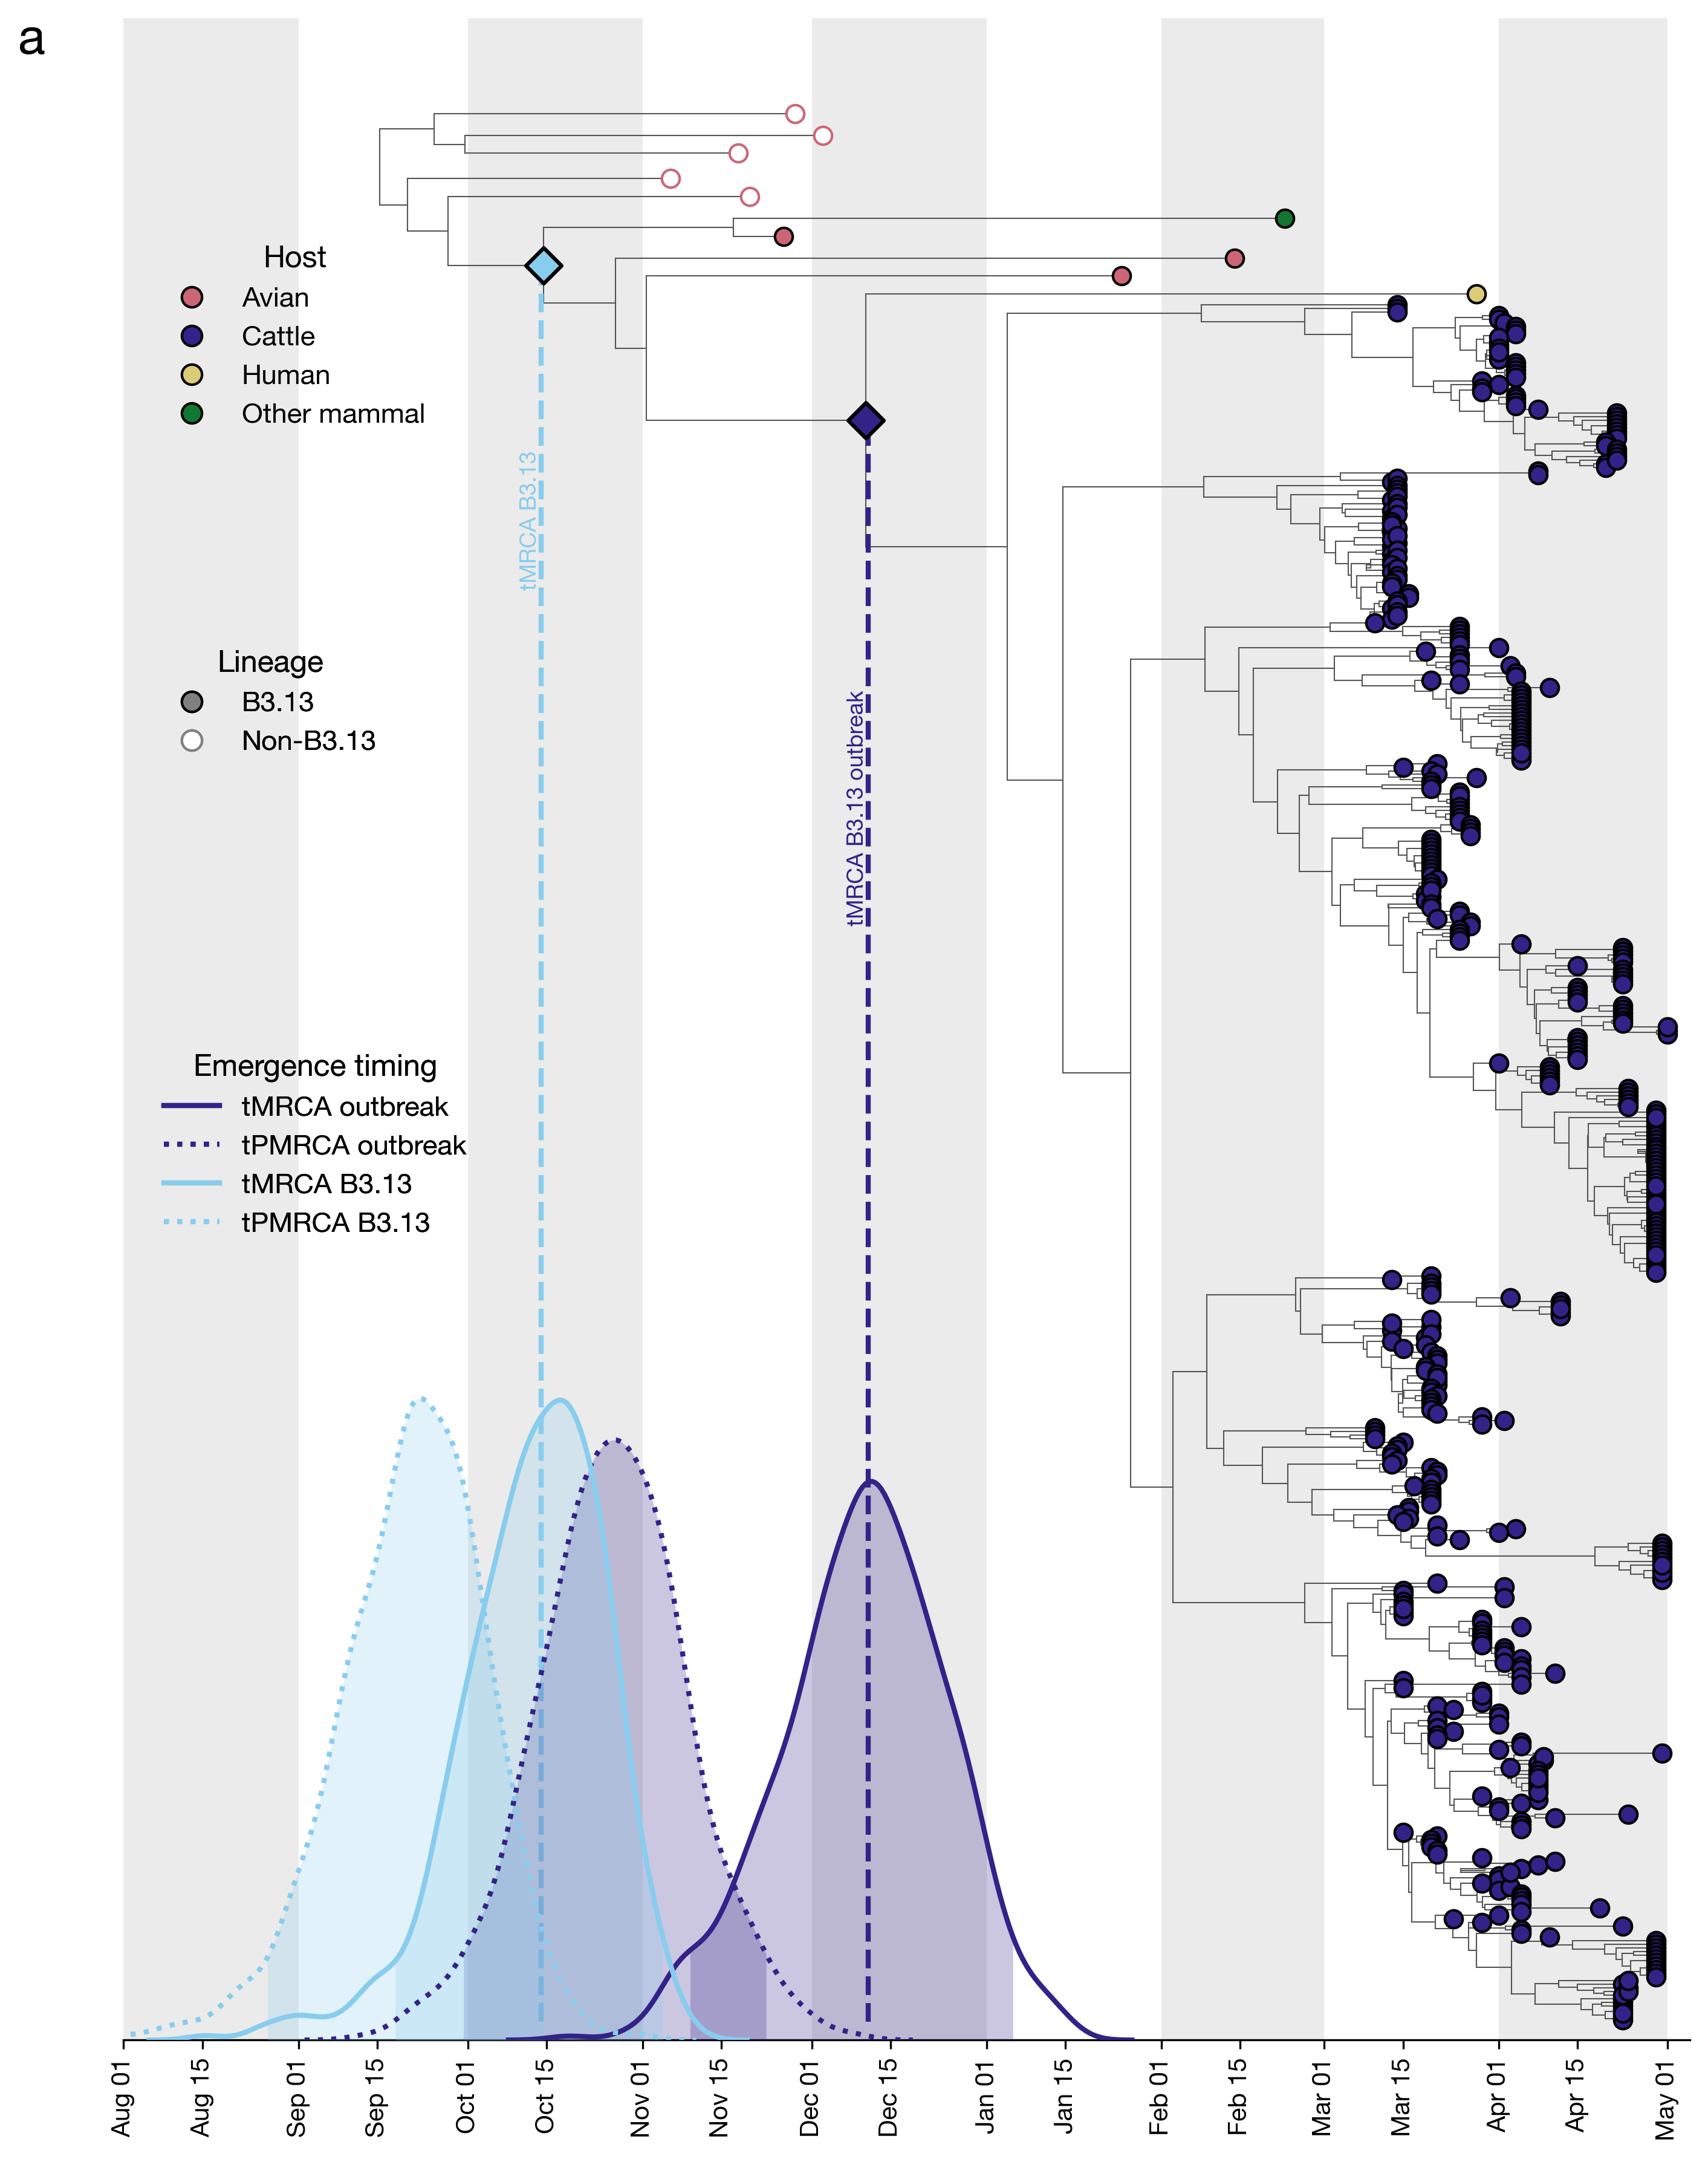

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import tol_colors as tc
import baltic as bt  # adjust import name if needed


def assign_absolute_times_from_root_heights(tree):
    """
    Given a baltic tree whose .height is measured from the root,
    infer a linear mapping

        absoluteTime = a + b * height

    using tip heights vs tip sampling dates from tip labels.

    Tip labels must contain at least one 'YYYY-MM-DD' token.
    """

    tip_heights = []
    tip_dates = []

    for tip in tree.getExternal():
        parts = tip.name.split('|')
        date_str = None
        for p in parts:
            # simple YYYY-MM-DD heuristic
            if len(p) == 10 and p[4] == '-' and p[7] == '-':
                date_str = p
                break

        if date_str is None:
            continue

        try:
            dec_date = bt.decimalDate(date_str)
        except Exception:
            continue

        h = getattr(tip, "height", None)
        if h is None:
            continue

        tip_heights.append(float(h))
        tip_dates.append(float(dec_date))

    if len(tip_heights) < 2:
        raise ValueError(
            "Not enough tips with parsable dates to fit height→time mapping."
        )

    tip_heights = np.array(tip_heights)
    tip_dates = np.array(tip_dates)

    # Fit linear mapping: date ≈ a + b * height
    b, a = np.polyfit(tip_heights, tip_dates, 1)  # slope b, intercept a

    # Assign absoluteTime to all nodes
    for node in tree.Objects:
        h = getattr(node, "height", None)
        if h is None:
            raise ValueError("Node missing .height — cannot assign absoluteTime.")
        node.absoluteTime = a + b * float(h)

    # Store mostRecent as max tip absoluteTime
    tree.mostRecent = max(
        node.absoluteTime for node in tree.getExternal()
        if getattr(node, "absoluteTime", None) is not None
    )

    return tree


def get_mrca(tree, taxa: List[str]):
    """
    Given a baltic tree and a list of tip names (taxa),
    return the MRCA node of those taxa, or None if not found.
    """
    mrca_node = None

    for k in tree.getInternal(): ## iterate over nodes
        all_children = list(k.leaves) ## fetch all descendant tips of node

        if all(c in all_children for c in taxa):
            if mrca_node is None or k.absoluteTime > mrca_node.absoluteTime:
                mrca_node = k

    return mrca_node


def plot_b313_tree_with_kdes(tt_sub_path, 
                             tmrcas_df, 
                             figsize=(12, 8),
                             b313_taxa_subset=b313_taxa_subset,
                             b313_outbreak_taxa_subset=b313_outbreak_taxa_subset):
    
    """
    B3.13-focused tree with KDEs:

      Tree:
        - x-axis = calendar time (decimal years; from absoluteTime)
        - color = host (avian, cattle, human, other_mammal)
        - fill vs hollow = lineage (B3.13 vs non-B3.13)

      KDEs (twin y-axis, same x scale):
        - tmrca_outbreak, tpmrca_outbreak (same color, solid/dashed)
        - tmrca_b313,   tpmrca_b313    (same color, solid/dashed)
    """

    # ---------- colors & markers ----------
    cset = tc.tol_cset('muted')

    host_colors = {
        'avian':        cset[0],
        'cattle':       cset[1],
        'human':        cset[2],
        'other_mammal': cset[3],
    }

    host_markers = {
        'avian': 'o',
        'cattle': 'd',
        'human': 's',
        'other_mammal': '^',
    }
    
    host_markers = {
        'avian': 'o',
        'cattle': 'o',
        'human': 'o',
        'other_mammal': 'o',
    }

    # KDE colors
    col_outbreak = cset[1]      # outbreak TMRCA curves
    col_b313_tmrca = cset[4]    # B3.13 TMRCA curves

    def parse_host_and_clade(name: str):
        """
        Assumes tip name ends with ...|HOST|CLADE,
        e.g. ...|avian|B3.13 or ...|cattle|other.
        Returns (host, clade).
        """
        parts = name.split('|')
        if len(parts) < 2:
            return 'other_mammal', 'other'
        host = parts[-2].lower()
        clade = parts[-1]

        if host not in ['avian', 'cattle', 'human', 'other_mammal']:
            if 'avian' in host:
                host = 'avian'
            elif 'cattle' in host:
                host = 'cattle'
            elif 'human' in host:
                host = 'human'
            else:
                host = 'other_mammal'

        return host, clade

    # ---------- load tree & assign absolute times ----------
    tree = bt.loadNewick(tt_sub_path)
    assign_absolute_times_from_root_heights(tree)

    x_attr = lambda k: k.absoluteTime
    
    # ----------- get B3.13 & outbreak MRCAs -----------
    b313_mrca = get_mrca(tree, b313_taxa_subset)
    b313_outbreak_mrca = get_mrca(tree, b313_outbreak_taxa_subset)

    # ---------- figure & main axis ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    
    # ---------- highlight focal nodes ----------
    focal_path=[k for k in tree.getExternal() if 'cattle' not in k.name]
    focal_path+=[k for k in tree.getInternal() if all(['cattle' not in lf for lf in k.leaves])]
    pad_nodes={k: 2 if k.is_node() and len(k.leaves)==4 else (2 if k.is_leaf() else 1) for k in focal_path}
    print(pad_nodes)
    tree.drawTree(pad_nodes=pad_nodes)
    
    # backbone tree
    tree.plotTree(ax, x_attr=x_attr, width=.5, colour='#555555')

    # ---------- tips ----------
    for tip in tree.getExternal():
        host, clade = parse_host_and_clade(tip.name)
        marker = host_markers.get(host, 'o')
        color = host_colors.get(host, 'lightgrey')

        x = x_attr(tip)
        y = tip.y
        s = 50

        if clade == 'B3.13':
            # B3.13 = filled
            face = color
            edge = 'k'
            lw = 1.0
        else:
            # non-B3.13 = hollow
            face = 'white'
            edge = color
            lw = 1.0

        ax.scatter(
            x, y,
            s=s,
            facecolor=face,
            edgecolor=edge,
            linewidth=lw,
            marker=marker,
            zorder=10,
        )
        
    
    # ---------- add diamonds at focal MRCA nodes ----------
    # KDE colors
    col_outbreak = cset[1]      # outbreak TMRCA curves
    col_b313_tmrca = cset[4]    # B3.13 TMRCA curves
    
    for mrca_node, label in [(b313_mrca, 'b313_mrca'), (b313_outbreak_mrca, 'b313_outbreak_mrca')]:
        if mrca_node is not None:
            # host, clade = parse_host_and_clade(mrca_node.name)
            marker = 'D'  # diamond for MRCA
            # color = host_colors.get(host, 'lightgrey')
            color = 'black'

            x = x_attr(mrca_node)
            y = mrca_node.y
            s = 100

            if label == 'b313_mrca':
                # B3.13 = filled
                face = col_b313_tmrca
                edge = 'k'
                lw = 1.5
                # b313_mrca_height = mrca_node.y
                plt.vlines(x=np.median(tmrcas_df['tmrca_b313']), ymin=0, ymax=mrca_node.y, colors=col_b313_tmrca, linestyles='dashed', linewidth=2)
                # plt.vlines(x=np.median(tmrcas_df['tpmrca_b313']), ymin=0, ymax=mrca_node.parent.y, colors=col_b313_tmrca, linestyles='dotted', linewidth=2)
                
                # add rotated text label above line
                ax.text(
                    x=np.median(tmrcas_df['tmrca_b313']) - 0.0005,
                    y=mrca_node.y - 90,
                    s='tMRCA B3.13',
                    color=col_b313_tmrca,
                    fontsize=9,
                    ha='right',
                    va='bottom',
                    rotation=90,
                )
                
            else:
                # non-B3.13 = hollow
                face = col_outbreak
                edge = 'k'
                lw = 1.5
                # b313_outbreak_mrca_height = mrca_node.y
                plt.vlines(x=np.median(tmrcas_df['tmrca_outbreak']), ymin=0, ymax=mrca_node.y, colors=col_outbreak, linestyles='dashed', linewidth=2)
                # plt.vlines(x=np.median(tmrcas_df['tpmrca_outbreak']), ymin=0, ymax=mrca_node.parent.y, colors=col_outbreak, linestyles='dotted', linewidth=2)
                
                # add rotated text label above line
                ax.text(
                    x=np.median(tmrcas_df['tmrca_outbreak']) - 0.0005,
                    y=mrca_node.y - 140,
                    s='tMRCA B3.13 outbreak',
                    color=col_outbreak,
                    fontsize=9,
                    ha='right',
                    va='bottom',
                    rotation=90,
                )

            ax.scatter(
                x, y,
                s=s,
                facecolor=face,
                edgecolor=edge,
                linewidth=lw,
                marker=marker,
                zorder=15,
                label=label,
            )

    # ---------- legends ----------
    # Host legend
    host_legend_handles = [
        Line2D(
            [0], [0],
            marker=host_markers[h],
            color='none',
            markerfacecolor=host_colors[h],
            markeredgecolor='black',
            markersize=8,
            label=h.replace('_', ' ').capitalize(),
        )
        for h in ['avian', 'cattle', 'human', 'other_mammal']
    ]
    legend_host = ax.legend(
        handles=host_legend_handles,
        title='Host',
        frameon=False,
        loc='upper left',
        bbox_to_anchor=(0.01, 0.9),
        fontsize=11,
        title_fontsize=12,
    )
    ax.add_artist(legend_host)

    # Lineage legend
    lineage_legend_handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor='grey',
            markeredgecolor='black',
            markersize=8,
            label='B3.13',
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor='white',
            markeredgecolor='grey',
            markersize=8,
            label='Non-B3.13',
        ),
    ]
    legend_lineage = ax.legend(
        handles=lineage_legend_handles,
        title='Lineage',
        frameon=False,
        loc='upper left',
        bbox_to_anchor=(0.01, 0.7),
        fontsize=11,
        title_fontsize=12,
    )
    ax.add_artist(legend_lineage)
    
    # ... after all the tree + tip + MRCA plotting, before tight_layout
    ymin, ymax = ax.get_ylim()
    if ymin < 0:
        # Crop off empty negative space so tree + vlines sit on the bottom
        ax.set_ylim(-5, ymax)
    
    # print y min, y max
    print(f"y min: {ax.get_ylim()[0]}, y max: {ax.get_ylim()[1]}")

    # ---------- KDEs on twin axis ----------
    twin_ax = ax.twinx()
                
    def kde_if_valid(col, color, linestyle, label):
        if col in tmrcas_df.columns:
            vals = tmrcas_df[col].dropna().values
            if len(vals) > 1 and vals.min() != vals.max():
                # 95% HPD (alpha = 0.05)
                hpd_low, hpd_high = hpd_single(vals, alpha=0.05)
                hpd_vals = vals[(vals >= hpd_low) & (vals <= hpd_high)]
                
                # Plot KDE line as before
                sns.kdeplot(
                    x=hpd_vals,
                    ax=twin_ax,
                    color=color,
                    linewidth=2,
                    linestyle=linestyle,
                    label=label,
                    # cut=0,
                )

                # Get the line that was just added
                kde_line = twin_ax.lines[-1]
                x_data = kde_line.get_xdata()
                y_data = kde_line.get_ydata()

                # Mask points within the HPD interval
                mask = (x_data >= hpd_low) & (x_data <= hpd_high)
                if mask.any():
                    twin_ax.fill_between(
                        x_data[mask],
                        0,
                        y_data[mask],
                        color=color,
                        alpha=0.25,
                        linewidth=0,
                    )
                    
    def kde_if_valid(col, color, linestyle, label):
        if col in tmrcas_df.columns:
            vals = tmrcas_df[col].dropna().values
            if len(vals) > 1 and vals.min() != vals.max():
                # 95% HPD (alpha = 0.05)
                hpd_low, hpd_high = hpd_single(vals, alpha=0.05)
                hpd_vals = vals[(vals >= hpd_low) & (vals <= hpd_high)]
                
                # Plot KDE line
                sns.kdeplot(
                    x=vals,
                    ax=twin_ax,
                    color=color,
                    linewidth=2,
                    linestyle=linestyle,
                    label=label,
                    # cut=0,
                )

                # Get the line that was just added
                kde_line = twin_ax.lines[-1]
                x_data = kde_line.get_xdata()
                y_data = kde_line.get_ydata()

                # Mask points within the HPD interval
                mask = (x_data >= hpd_low) & (x_data <= hpd_high)
                if mask.any():
                    x_hpd = x_data[mask]
                    y_hpd = y_data[mask]

                    # Fill HPD region
                    twin_ax.fill_between(
                        x_hpd,
                        0,
                        y_hpd,
                        color=color,
                        alpha=0.25,
                        linewidth=0,
                    )



    # Outbreak
    kde_if_valid('tmrca_outbreak',  col_outbreak, '-',  'tMRCA outbreak')
    kde_if_valid('tpmrca_outbreak', col_outbreak, ':', 'tPMRCA outbreak')

    # B3.13
    kde_if_valid('tmrca_b313',  col_b313_tmrca, '-',  'tMRCA B3.13')
    kde_if_valid('tpmrca_b313', col_b313_tmrca, ':', 'tPMRCA B3.13')

    # Compress KDE y-axis & hide it
    if twin_ax.lines:
        ymax = twin_ax.get_ylim()[1]
        twin_ax.set_ylim(0, ymax * 3)
    twin_ax.set_yticks([])
    twin_ax.set_yticklabels([])
    twin_ax.set_ylabel(None)
    for loc in twin_ax.spines:
        twin_ax.spines[loc].set_visible(False)
    
    # KDE legend on right
    kde_handles, kde_labels = twin_ax.get_legend_handles_labels()
    if kde_handles:
        legend_kde = twin_ax.legend(
            kde_handles,
            kde_labels,
            frameon=False,
            loc='upper left',
            bbox_to_anchor=(0.01, 0.5),
            fontsize=11,
            title='Emergence timing',
            title_fontsize=12,
        )
        
    twin_ax.add_artist(legend_kde)
    
    # print ymin, ymax of twin_ax
    print(f"twin_ax ymin: {twin_ax.get_ylim()[0]}, twin_ax ymax: {twin_ax.get_ylim()[1]}")

    # ---------- x-axis as calendar time ----------
    month_timeline = ['2023-%02d-01' % m for m in range(8, 13)]
    month_timeline += ['2024-%02d-01' % m for m in range(1, 6)]

    every = 14
    end = 28
    calendar_timeline = []
    calendar_timeline += ['2023-08-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2023-09-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2023-10-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2023-11-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2023-12-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-01-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-02-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-03-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-04-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-05-%02d' % d for d in range(1, end, every)]

    ax.set_xticks([bt.decimalDate(d) for d in calendar_timeline])
    ax.set_xticklabels(
        [bt.convertDate(d, '%Y-%m-%d', '%b %d') for d in calendar_timeline],
        rotation=90,
    )

    # alternating month shading
    for i in range(len(month_timeline) - 1):
        if i % 2 == 0:
            ax.axvspan(
                bt.decimalDate(month_timeline[i]),
                bt.decimalDate(month_timeline[i + 1]),
                fc='k',
                ec='none',
                alpha=0.08,
                zorder=0,
            )

    # x-range: outbreak window (tweak if needed)
    ax.set_xlim(
        bt.decimalDate('2023-08-01'),
        bt.decimalDate('2024-05-05'),
    )

    # ---------- cosmetics ----------
    ax.set_yticks([])
    ax.set_yticklabels([])

    for loc in ax.spines:
        if loc != 'bottom':
            ax.spines[loc].set_visible(False)

    # ax.set_xlabel("Time", fontsize=11)

    fig.tight_layout()
    return fig, ax, twin_ax


b313_taxa_subset = '''A/goose/Colorado/23-038138-001/2023|H5N1|USA-CO|2023-11-26|avian|B3.13
A/skunk/New_Mexico/24-006483-001/2024|H5N1|USA-NM|2024-02-23|other_mammal|B3.13
A/peregrine_falcon/California/24-005915-001/2024|H5N1|USA-CA|2024-02-14|avian|B3.13
A/Canada_goose/Wyoming/24-003692-001/2024|H5N1|USA-WY|2024-01-25|avian|B3.13
A/Texas/37/2024|H5N1|USA-TX|2024-03-28|human|B3.13
A/cattle/Texas/24-009110-023/2024|H5N1|USA-TX|2024-03-14|cattle|B3.13'''.strip().split('\n')
b313_outbreak_taxa_subset = b313_taxa_subset[4:]
fig, ax, twin_ax = plot_b313_tree_with_kdes(tt_sub_path, tmrcas_df, figsize=(9, 12))
# add letter labels
labels = ['a']
ax.text(-0.05, 1, labels[0], transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='top', ha='right')
# fig.tight_layout()

plt.savefig('fig2.b313_tree_with_kdes.png', dpi=300)
plt.savefig('fig2.b313_tree_with_kdes.pdf', dpi=300)
plt.show()

# tMRCAs for all segments

In [ ]:
def assign_heights_to_nodes(tree, max_date=toYearFraction('2024-12-26')):
    for node in tree.traverse_preorder():
        if node.is_root():
            node.height = tree.height()
            node.date = toDatestring(max_date - node.height)
            continue
        node.height = node.parent.height - node.edge_length
        node.date = toDatestring(max_date - node.height)
    
b313_dir = '../analysis/b313/beast_bird_cattle_combined/'
tmrcas_segment_dfs = {}
for segment in ['PB2','PB1','PA','HA','NP','NA','MP','NS','PA-HA-NA-MP']:
    trees_path = f'{b313_dir}{segment}/combined/combined.resampled.trees'
    trees = treeswift.read_tree_nexus(trees_path)

    t = list(trees.values())[-1]
    max_date = '2020-01-01'
    for k in t.traverse_leaves():
        date_str = k.label.split('|')[-3]
        if date_str > max_date:
            max_date = date_str

    tmrcas = []
    for k in trees:
        if 'STATE' not in k:
            continue
        t = trees[k]
        assign_heights_to_nodes(t, max_date=toYearFraction(max_date))
        tmrca_outbreak = t.mrca(b313_outbreak_leaves)
        tmrca_b313 = t.mrca(b313_leaves)
        tmrcas.append((tmrca_outbreak.date, tmrca_outbreak.parent.date, tmrca_b313.date, tmrca_b313.parent.date))

    tmrcas_df = pd.DataFrame(tmrcas, columns=['tmrca_outbreak', 'tpmrca_outbreak', 'tmrca_b313', 'tpmrca_b313'])
    # apply toYearFraction to convert date strings to decimal years
    for col in tmrcas_df.columns:
        tmrcas_df[col] = tmrcas_df[col].map(toYearFraction)

    tmrcas_segment_dfs[segment] = tmrcas_df

In [14]:
# save tmrcas_segment_dfs to json
import json
tmrcas_segment_dfs_json = {}
for segment, df in tmrcas_segment_dfs.items():
    tmrcas_segment_dfs_json[segment] = df.to_dict(orient='list')

with open('tmrcas_segment_dfs.json', 'w') as f:
    json.dump(tmrcas_segment_dfs_json, f)

In [2]:
# load json
with open('tmrcas_segment_dfs.json', 'r') as f:
    tmrcas_segment_dfs_json = json.load(f)
    
# convert back to dataframes
tmrcas_segment_dfs = {}
for segment, data in tmrcas_segment_dfs_json.items():
    tmrcas_segment_dfs[segment] = pd.DataFrame(data)

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_96120/2979601668.py:322: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


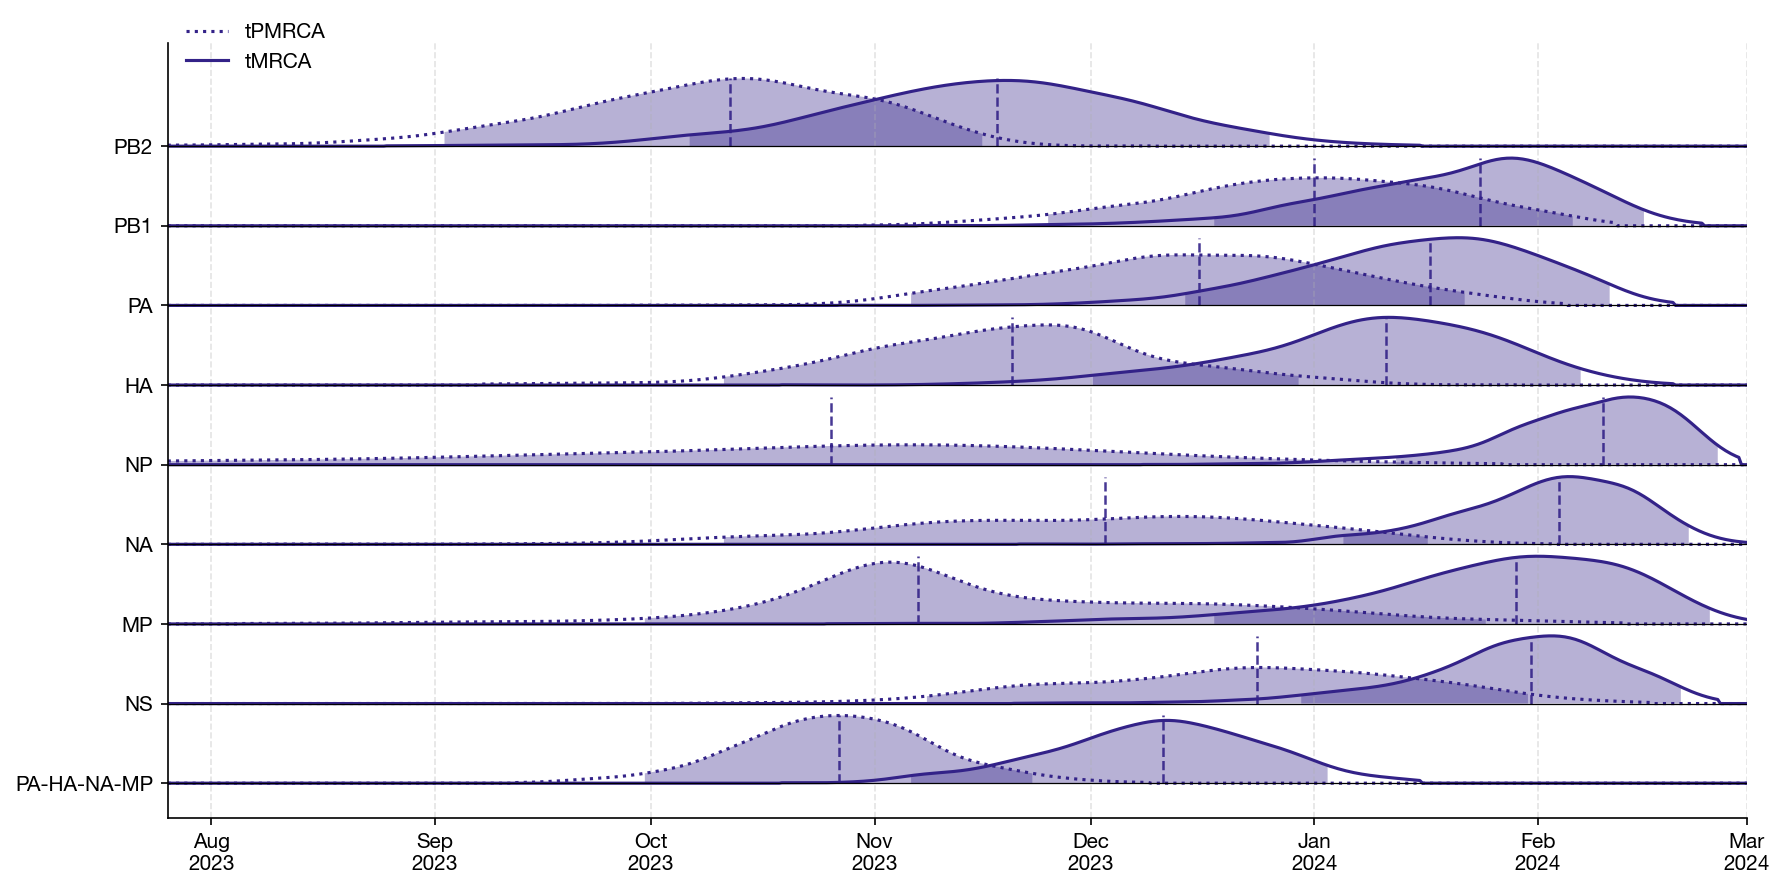

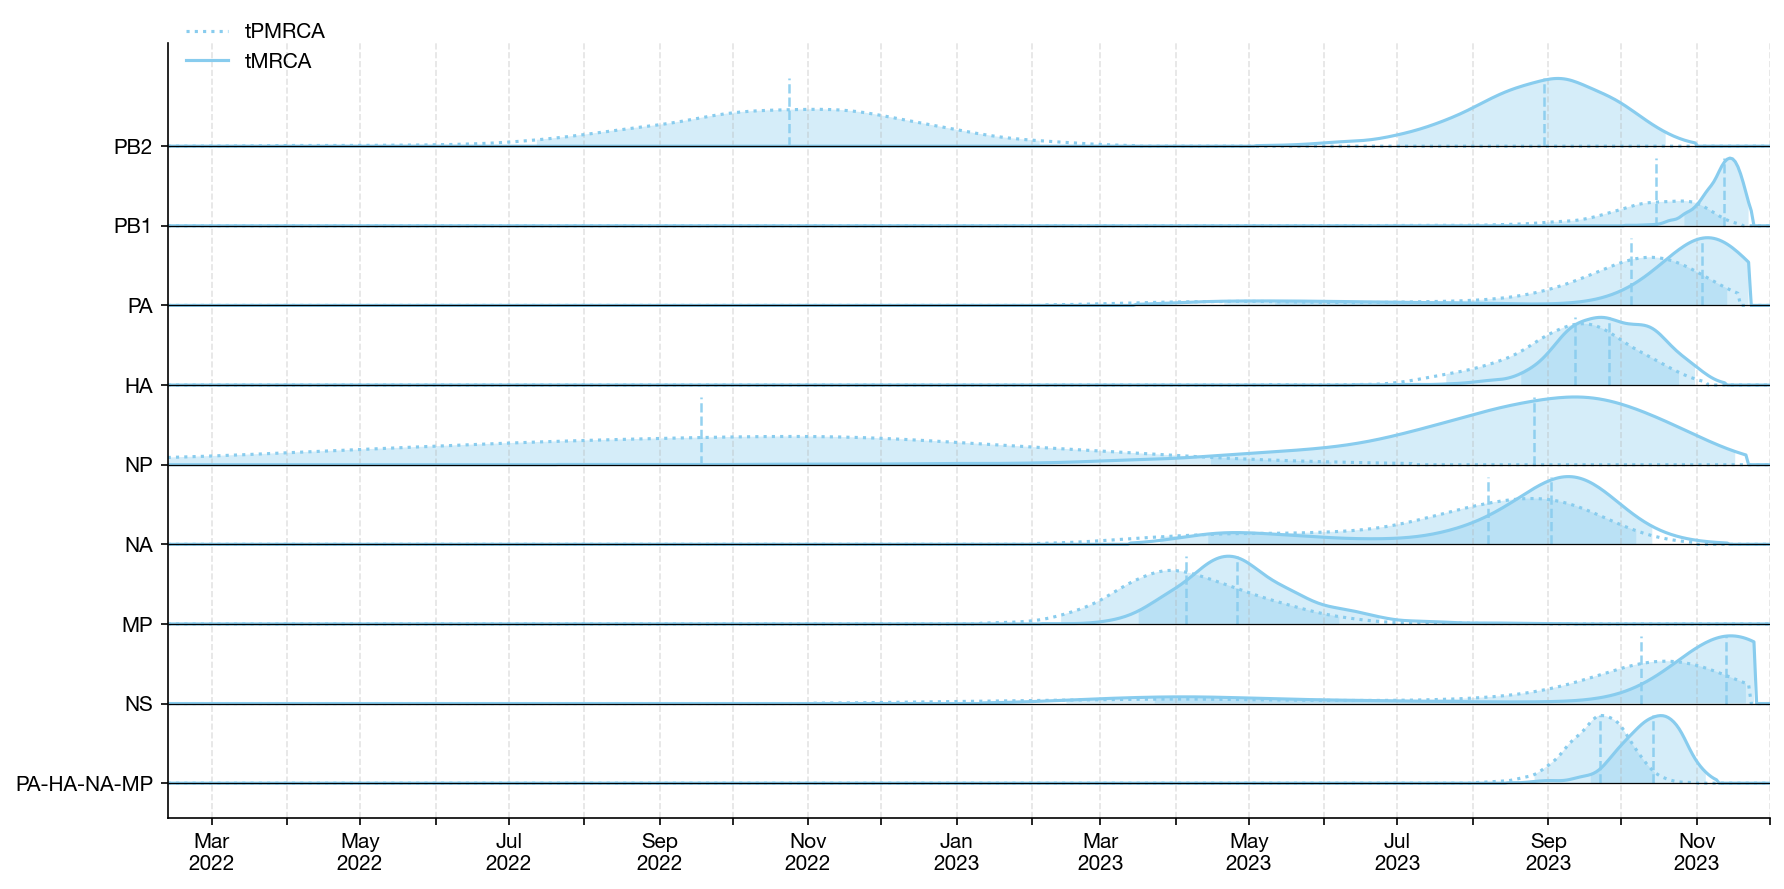

In [ ]:
# --- HPD helper ---
def _hpd_interval(x: np.ndarray, mass: float = 0.95):
    """
    Approximate HPD interval (for unimodal distributions).
    Returns (low, high).
    """
    x = np.sort(x[np.isfinite(x)])
    n = len(x)
    if n == 0:
        return (np.nan, np.nan)
    k = int(np.floor(mass * n))
    if k < 1:
        return (x.min(), x.max())
    widths = x[k:] - x[: n - k]
    i = np.argmin(widths)
    return (x[i], x[i + k])

# --- decimal year → datetime ---
def decimal_to_datetime(decimal_year: float) -> datetime:
    y = int(decimal_year)
    frac = decimal_year - y
    start = datetime(y, 1, 1)
    end = datetime(y + 1, 1, 1)
    return start + (end - start) * frac

# --- strict KDE with cut=0 ---
def _kde_gaussian(x: np.ndarray, grid: np.ndarray, bandwidth: float | None = None) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = x.size
    if n == 0:
        return np.zeros_like(grid)

    std = x.std(ddof=1) if n > 1 else 0.0
    if bandwidth is None:
        if std <= 0:
            std = max(1.0, np.abs(x).mean() * 1e-3 if n > 0 else 1.0)
        bandwidth = 1.06 * std * (n ** (-1/5))  # Silverman
        bandwidth = max(bandwidth, np.finfo(float).eps)

    u = (grid[None, :] - x[:, None]) / bandwidth
    dens = np.exp(-0.5 * u**2).sum(axis=0) / (n * bandwidth * np.sqrt(2 * np.pi))

    area = np.trapezoid(dens, grid)
    if area > 0:
        dens /= area

    x_lo, x_hi = x.min(), x.max()
    dens[(grid < x_lo) | (grid > x_hi)] = 0.0
    return dens

# --- prep dataframe ---
def _prep_values(df_long: pd.DataFrame) -> pd.DataFrame:
    d = df_long[["analysis", "unit", "value"]].dropna()
    d = d.assign(
        _date=d["value"].map(decimal_to_datetime),
    )
    d = d.assign(_datenum=date2num(d["_date"]))
    return d

# --- plotting ---
def plot_ridgeline_two_sets(d1, d2, units=None, label1="outbreak", label2="stem",
                            c1="#1f77b4", c2="#d62728", figsize=(11, 9)):
    d1 = _prep_values(d1)
    d2 = _prep_values(d2)

    if units is None:
        units = sorted(set(d1["unit"]).union(d2["unit"]))

    all_nums = np.concatenate([d1["_datenum"], d2["_datenum"]])
    all_nums = all_nums[np.isfinite(all_nums)]
    x_lo, x_hi = np.quantile(all_nums, [0.005, .995])
    x_hi_dt = mdates.num2date(x_hi)
    # Extend x_hi to 1st of next month
    year, month = x_hi_dt.year, x_hi_dt.month
    if month == 12:
        first_next = datetime(year + 1, 1, 1)
    else:
        first_next = datetime(year, month + 1, 1)
    x_hi = mdates.date2num(first_next)

    grid = np.linspace(x_lo, x_hi, 600)

    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    row_height = 1.0
    scale_max = 0.85

    for i, u in enumerate(units):
        x1 = d1.loc[d1["unit"] == u, "_datenum"]
        x2 = d2.loc[d2["unit"] == u, "_datenum"]

        # trim to HPD
        x1_lo, x1_hi = _hpd_interval(x1, mass=0.95)
        x2_lo, x2_hi = _hpd_interval(x2, mass=0.95)
        x1 = x1[(x1 >= x1_lo) & (x1 <= x1_hi)].to_numpy()
        x2 = x2[(x2 >= x2_lo) & (x2 <= x2_hi)].to_numpy()

        y1 = _kde_gaussian(x1, grid) if x1.size else np.zeros_like(grid)
        y2 = _kde_gaussian(x2, grid) if x2.size else np.zeros_like(grid)

        denom = max(y1.max(), y2.max(), 1e-12)
        y1s = (y1 / denom) * scale_max
        y2s = (y2 / denom) * scale_max

        base = len(units) - 1 - i

        # filled curves
        ax.fill_between(grid, base, base + y1s, facecolor=c1, alpha=0.35, lw=0)
        ax.plot(grid, base + y1s, color=c1, lw=1.5, label=label1 if i == 0 else None)

        ax.fill_between(grid, base, base + y2s, facecolor=c2, alpha=0.35, lw=0)
        ax.plot(grid, base + y2s, color=c2, lw=1.5, label=label2 if i == 0 else None)

        # neutral baseline
        ax.hlines(base, x_lo, x_hi, color="black", lw=0.6, alpha=1, zorder=100)

        # --- medians ---
        if x1.size:
            m1 = np.median(x1)
            ax.vlines(m1, base, base + scale_max, color=c1, lw=1.2, ls="--", alpha=0.9)
        if x2.size:
            m2 = np.median(x2)
            ax.vlines(m2, base, base + scale_max, color=c2, lw=1.2, ls="--", alpha=0.9)

    # y ticks
    ax.set_yticks(np.arange(len(units)))
    ax.set_yticklabels(list(reversed(units)))

    # x axis as dates
    ax.set_xlim(x_lo, x_hi)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_ha("center")

    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.grid(axis="x", which="major", ls="--", alpha=0.35)

    # legend once
    ax.legend(frameon=False, loc="upper left", ncols=2)

    # aesthetics
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    return fig, ax


# def plot_ridgeline_two_sets(d1, d2, units=None, label1="outbreak", label2="stem", linestyle1='-', linestyle2='-',
#                             c1="#1f77b4", c2="#d62728", figsize=(11, 9), ax=None):

def plot_ridgeline_two_sets(
    d1, d2, units=None,
    label1="outbreak", label2="stem",
    linestyle1='-', linestyle2='-',
    c1="#1f77b4", c2="#d62728",
    figsize=(11, 9),
    ax=None,
    xtick_every=1,   # NEW
):

    d1 = _prep_values(d1)
    d2 = _prep_values(d2)

    if units is None:
        units = sorted(set(d1["unit"]).union(d2["unit"]))

    all_nums = np.concatenate([d1["_datenum"], d2["_datenum"]])
    all_nums = all_nums[np.isfinite(all_nums)]
    x_lo, x_hi = np.quantile(all_nums, [0.005, 0.995])

    x_hi_dt = mdates.num2date(x_hi)
    # Extend x_hi to 1st of next month
    year, month = x_hi_dt.year, x_hi_dt.month
    if month == 12:
        first_next = datetime(year + 1, 1, 1)
    else:
        first_next = datetime(year, month + 1, 1)
    x_hi = mdates.date2num(first_next)

    grid = np.linspace(x_lo, x_hi, 600)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, dpi=150)

    row_height = 1.0
    scale_max = 0.85

    for i, u in enumerate(units):
        # --- full data for each unit ---
        x1_all = d1.loc[d1["unit"] == u, "_datenum"].to_numpy()
        x2_all = d2.loc[d2["unit"] == u, "_datenum"].to_numpy()

        # --- HPD intervals (on full data) ---
        if x1_all.size:
            x1_lo, x1_hi = _hpd_interval(x1_all, mass=0.95)
        else:
            x1_lo = x1_hi = np.nan

        if x2_all.size:
            x2_lo, x2_hi = _hpd_interval(x2_all, mass=0.95)
        else:
            x2_lo = x2_hi = np.nan

        # --- KDE on full distributions ---
        y1 = _kde_gaussian(x1_all, grid) if x1_all.size else np.zeros_like(grid)
        y2 = _kde_gaussian(x2_all, grid) if x2_all.size else np.zeros_like(grid)

        denom = max(y1.max(), y2.max(), 1e-12)
        y1s = (y1 / denom) * scale_max
        y2s = (y2 / denom) * scale_max

        base = len(units) - 1 - i

        # --- HPD masks on the grid ---
        mask1 = np.isfinite(x1_lo) & np.isfinite(x1_hi) & (grid >= x1_lo) & (grid <= x1_hi)
        mask2 = np.isfinite(x2_lo) & np.isfinite(x2_hi) & (grid >= x2_lo) & (grid <= x2_hi)

        # --- filled HPD regions only ---
        if mask1.any():
            ax.fill_between(
                grid[mask1],
                base,
                base + y1s[mask1],
                facecolor=c1,
                alpha=0.35,
                lw=0,
            )
        if mask2.any():
            ax.fill_between(
                grid[mask2],
                base,
                base + y2s[mask2],
                facecolor=c2,
                alpha=0.35,
                lw=0,
            )

        # --- lines over the full KDE support ---
        ax.plot(
            grid,
            base + y1s,
            color=c1,
            lw=1.5,
            label=label1 if i == 0 else None,
            linestyle=linestyle1,
            # cut=0
        )
        ax.plot(
            grid,
            base + y2s,
            color=c2,
            lw=1.5,
            label=label2 if i == 0 else None,
            linestyle=linestyle2,
        )

        # neutral baseline
        ax.hlines(base, x_lo, x_hi, color="black", lw=0.6, alpha=1, zorder=100)

        # --- medians (of full distributions) ---
        if x1_all.size:
            m1 = np.median(x1_all)
            ax.vlines(m1, base, base + scale_max, color=c1, lw=1.2, ls="--", alpha=0.9)
        if x2_all.size:
            m2 = np.median(x2_all)
            ax.vlines(m2, base, base + scale_max, color=c2, lw=1.2, ls="--", alpha=0.9)

    # y ticks
    ax.set_yticks(np.arange(len(units)))
    ax.set_yticklabels(list(reversed(units)))
        
    # x axis as dates
    ax.set_xlim(x_lo, x_hi)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

    # optionally thin x tick labels
    for i, label in enumerate(ax.get_xticklabels()):
        label.set_rotation(0)
        label.set_ha("center")
        if xtick_every > 1 and (i % xtick_every != 0):
            label.set_visible(False)


    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.grid(axis="x", which="major", ls="--", alpha=0.35)

    # legend once
    ax.legend(frameon=False, loc="upper left", ncols=1, bbox_to_anchor=(0, 1.05))

    # aesthetics
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    
    
tmrcas_analyses_dfs = {'tmrca_outbreak': pd.DataFrame(), 'tpmrca_outbreak': pd.DataFrame(), 'tmrca_b313': pd.DataFrame(), 'tpmrca_b313': pd.DataFrame()}
for segment, df in tmrcas_segment_dfs.items():
    for col in tmrcas_analyses_dfs.keys():
        df_sub = df[[col]].copy()
        df_sub = df_sub.rename(columns={col: 'value'})
        df_sub['unit'] = segment
        df_sub['analysis'] = 'beast_bird_cattle_combined'
        tmrcas_analyses_dfs[col] = pd.concat([tmrcas_analyses_dfs[col], df_sub], ignore_index=True)

# KDE colors
import tol_colors as tc
cset = tc.tol_cset('muted')
col_outbreak = cset[1]      # outbreak TMRCA curves
col_b313_tmrca = cset[4]    # B3.13 TMRCA curves

plot_ridgeline_two_sets(
    d1=tmrcas_analyses_dfs['tpmrca_outbreak'],
    d2=tmrcas_analyses_dfs['tmrca_outbreak'],
    label1="tPMRCA",
    label2="tMRCA",
    c1=col_outbreak,
    c2=col_outbreak,
    linestyle1=':',
    linestyle2='-',
    figsize=(12, 6),
    units=["PB2","PB1","PA","HA","NP","NA","MP","NS","PA-HA-NA-MP"],
)

plot_ridgeline_two_sets(
    d1=tmrcas_analyses_dfs['tpmrca_b313'],
    d2=tmrcas_analyses_dfs['tmrca_b313'],
    label1="tPMRCA",
    label2="tMRCA",
    c1=col_b313_tmrca,
    c2=col_b313_tmrca,
    linestyle1=':',
    linestyle2='-',
    figsize=(12, 6),
    units=["PB2","PB1","PA","HA","NP","NA","MP","NS","PA-HA-NA-MP"],
    xtick_every=2,  # show every 2nd month label
)

plt.savefig('../figures/fig2.b313_tmrca_ridgeline_outbreak.png', dpi=300)
plt.savefig('../figures/fig2.b313_tmrca_ridgeline_outbreak.pdf', dpi=300)
plt.show()

In [12]:
tmrcas_analyses_dfs['tmrca_outbreak']

for key in tmrcas_analyses_dfs:
    temp_df = tmrcas_analyses_dfs[key]
    temp_df = temp_df[temp_df['unit'] == 'PA-HA-NA-MP']
    
    median = temp_df['value'].median()
    hpd_low, hpd_high = hpd_single(temp_df['value'], alpha=0.05)
    
    print(f"{key}: \n\tmedian={median:.4f}, \n\tHPD 95% = ({hpd_low:.4f}, {hpd_high:.4f})\n\tHPD 95% dates = ({toDatestring(median)}, ({toDatestring(hpd_low)}, {toDatestring(hpd_high)})\n")

tmrca_outbreak: 
	median=2023.9425, 
	HPD 95% = (2023.8548, 2024.0137)
	HPD 95% dates = (2023-12-10, (2023-11-09, 2024-01-06)

tpmrca_outbreak: 
	median=2023.8192, 
	HPD 95% = (2023.7452, 2023.8932)
	HPD 95% dates = (2023-10-26, (2023-09-30, 2023-11-22)

tmrca_b313: 
	median=2023.7836, 
	HPD 95% = (2023.7123, 2023.8438)
	HPD 95% dates = (2023-10-13, (2023-09-18, 2023-11-05)

tpmrca_b313: 
	median=2023.7233, 
	HPD 95% = (2023.6493, 2023.7863)
	HPD 95% dates = (2023-09-21, (2023-08-26, 2023-10-14)



# Skygrid reconstructions

In [17]:
fasta_path = '../data/processed/updated/new/for_joel/PA-HA-NA-MP_no_overlap.v2.fasta'
fasta = readFASTA(fasta_path)
avian_max_date = '2000-01-01'
cattle_max_date = '2000-01-01'
for k in fasta:
    d = k.split('|')[-3]
    if 'cattle' in k:
        if d > cattle_max_date:
            cattle_max_date = d
    elif 'avian' in k:
        if d > avian_max_date:
            avian_max_date = d
avian_max_date, cattle_max_date

('2024-12-17', '2024-12-26')

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_57397/2326693205.py:102: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


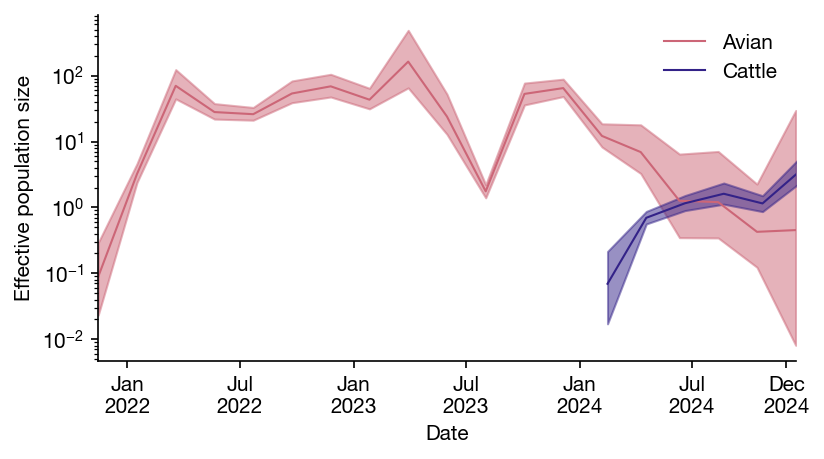

In [18]:
cattle_log_path = '../analysis/b313/beast_bird_cattle_separate/cattle/PA-HA-NA-MP-multiClock/PA-HA-NA-MP_no_overlap.RC.cattle_human.log'
avian_log_path = '../analysis/b313/beast_bird_cattle_separate/avian/PA-HA-NA-MP-multiClock/bird_skunk.seed1.PA-HA-NA-MP_no_overlap.RC.bird_skunk.log'

cattle_burnin = 10000000
avian_burnin = 25000000

import numpy as np
import pandas as pd
from datetime import datetime

def year_fraction_to_datetime(yf):
    year = int(np.floor(yf))
    remainder = yf - year
    start = datetime(year, 1, 1)
    end = datetime(year + 1, 1, 1)
    return start + (end - start) * remainder

def datetime_to_year_fraction(dt):
    start = datetime(dt.year, 1, 1)
    end = datetime(dt.year + 1, 1, 1)
    return dt.year + (dt - start).total_seconds() / (end - start).total_seconds()

def set_jan_jul_ticks_with_last_month(ax, xmin_frac, xmax_frac):
    dt_min = year_fraction_to_datetime(xmin_frac)
    dt_max = year_fraction_to_datetime(xmax_frac)

    # Jan/Jul ticks
    ticks_dt = pd.date_range(
        start=datetime(dt_min.year, 1, 1),
        end=datetime(dt_max.year, 7, 1),
        freq="6MS"  # Jan/Jul
    )

    # Ensure we start at/after dt_min (month-aligned)
    ticks_dt = ticks_dt[ticks_dt >= dt_min.replace(day=1, hour=0, minute=0, second=0, microsecond=0)]

    # Force last tick to be the month of max date (month start)
    last_dt = dt_max.replace(day=1, hour=0, minute=0, second=0, microsecond=0)
    if len(ticks_dt) == 0 or ticks_dt[-1] != last_dt:
        ticks_dt = ticks_dt.append(pd.DatetimeIndex([last_dt]))

    # Convert to fractional-year positions
    ticks_frac = [datetime_to_year_fraction(t.to_pydatetime()) for t in ticks_dt]

    ax.set_xticks(ticks_frac)
    ax.set_xticklabels([t.strftime("%b\n%Y") for t in ticks_dt])



def skygrid_reconstruction(log_path, burnin, final_date, cutoff):
    log = pd.read_csv(log_path, sep='\t', comment='#')
    log['state'] = log['state'].apply(lambda x: int(x))
    log = log[log['state'] > burnin]
    
    skygrid_columns = [c for c in log.columns if 'skygrid.logPopSize' in c]
    skygrid_results = {}
    for c in skygrid_columns:
        median = log[c].median()
        hpd_vals = hpd_single(log[c].values, alpha=0.05)
        hpd_low = hpd_vals[0]
        hpd_high = hpd_vals[1]
        skygrid_results[c.split('logPopSize')[-1]] = {
            'median': np.exp(median),
            'hpd_low': np.exp(hpd_low),
            'hpd_high': np.exp(hpd_high),
            'date': final_date,
        }
        
        final_date -= cutoff/(len(skygrid_columns) - 1)
        
        if median < -2:
            break
    
    skygrid_df = pd.DataFrame.from_dict(skygrid_results)
    
    age_median = np.median(log['age(root)'])
    age_hpd = hpd_single(log['age(root)'].values, alpha=0.05)
    
    return skygrid_df.T, age_hpd


def plot_skygrid(skygrid_df, bin_cutoff=None, ax=None, figsize=(6,6), color='k', label=None):
    if not ax:
        fig, ax = plt.subplots(figsize=figsize, dpi=150)
                
    ax.plot(skygrid_df['date'], skygrid_df['median'], color=color, lw=1, label=label)
    # ax.plot(skygrid_df['date'], skygrid_df['hpd_low'], color=color, lw=2)
    # ax.plot(skygrid_df['date'], skygrid_df['hpd_high'], color=color, lw=2)
    ax.fill_between(
        skygrid_df['date'],
        skygrid_df['hpd_low'],
        skygrid_df['hpd_high'],
        color=color,
        alpha=0.5,
    )
    
    ax.set_yscale('log')
    
    return ax
    
import tol_colors as tc
cset = tc.tol_cset('muted')
col_outbreak = cset[1]      # outbreak TMRCA curves
col_b313_tmrca = cset[0]    # B3.13 TMRCA curves

cattle_skygrid_df, cattle_tmrca = skygrid_reconstruction(cattle_log_path, cattle_burnin, final_date=toYearFraction(cattle_max_date)-1/365, cutoff=6)
avian_skygrid_df, avian_tmrca = skygrid_reconstruction(avian_log_path, avian_burnin, final_date=toYearFraction(avian_max_date)-1/365, cutoff=6) 

fig, ax = plt.subplots(figsize=(6, 3), dpi=150)
plot_skygrid(avian_skygrid_df, ax=ax, color=col_b313_tmrca, label='Avian')
plot_skygrid(cattle_skygrid_df, ax=ax, color=col_outbreak, label="Cattle")

xmin = avian_skygrid_df['date'].min()
xmax = avian_skygrid_df['date'].max()
ax.set_xlim(xmin, xmax)
set_jan_jul_ticks_with_last_month(ax, xmin, xmax)
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel("Date")
ax.set_ylabel("Effective population size")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

plt.savefig('../figures/fig2.b313_skygrid.png', dpi=300)
plt.savefig('../figures/fig2.b313_skygrid.pdf', dpi=300)
plt.show()

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_57397/2120530874.py:3: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


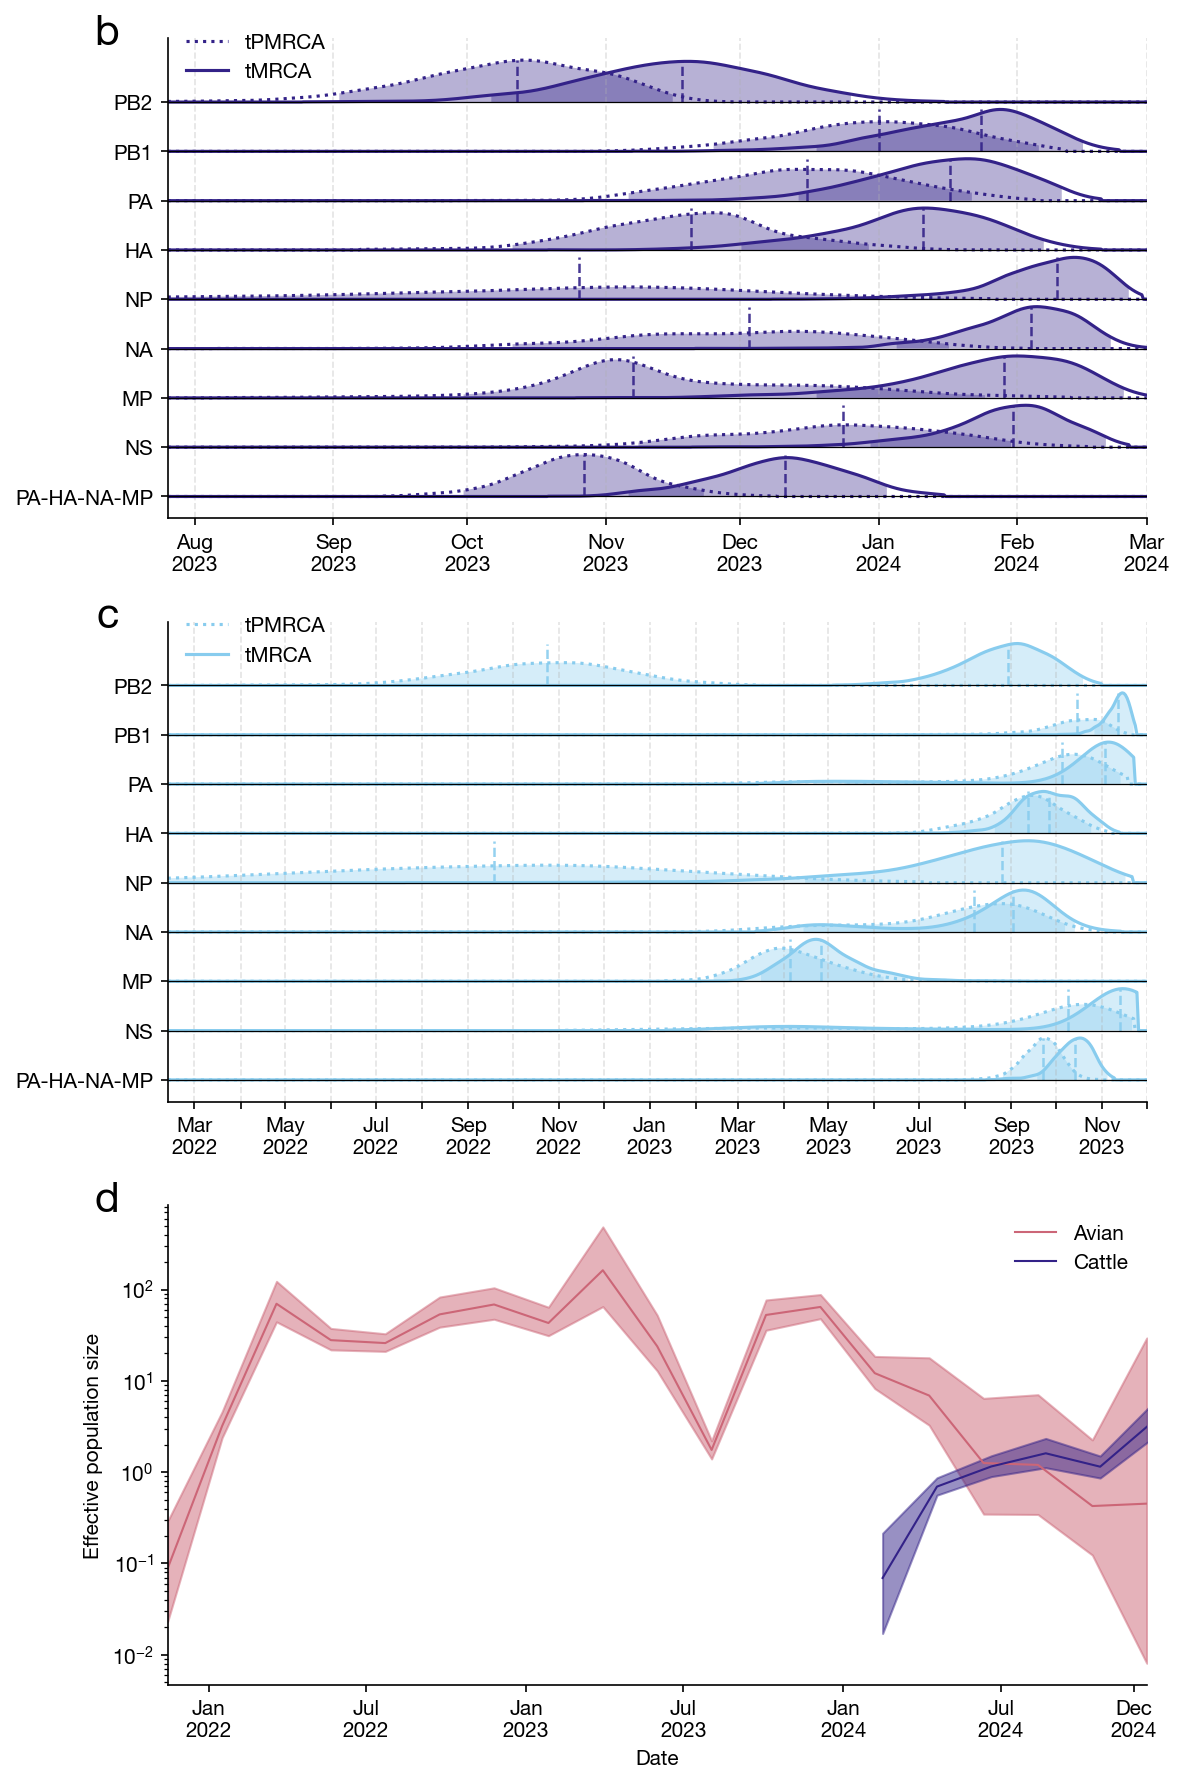

In [24]:
# KDE colors
import tol_colors as tc
cset = tc.tol_cset('muted')
col_outbreak = cset[1]      # outbreak TMRCA curves
col_b313_tmrca = cset[4]    # B3.13 TMRCA curves
col_avian_skygrid = cset[0]  # avian skygrid

cattle_skygrid_df, cattle_tmrca = skygrid_reconstruction(cattle_log_path, cattle_burnin, final_date=toYearFraction(cattle_max_date)-1/365, cutoff=6)
avian_skygrid_df, avian_tmrca = skygrid_reconstruction(avian_log_path, avian_burnin, final_date=toYearFraction(avian_max_date)-1/365, cutoff=6) 

fig, ax = plt.subplots(3, 1, figsize=(8, 12), dpi=150)

plot_ridgeline_two_sets(
    d1=tmrcas_analyses_dfs['tpmrca_outbreak'],
    d2=tmrcas_analyses_dfs['tmrca_outbreak'],
    label1="tPMRCA",
    label2="tMRCA",
    c1=col_outbreak,
    c2=col_outbreak,
    linestyle1=':',
    linestyle2='-',
    figsize=(12, 6),
    units=["PB2","PB1","PA","HA","NP","NA","MP","NS","PA-HA-NA-MP"],
    ax=ax[0],
)

plot_ridgeline_two_sets(
    d1=tmrcas_analyses_dfs['tpmrca_b313'],
    d2=tmrcas_analyses_dfs['tmrca_b313'],
    label1="tPMRCA",
    label2="tMRCA",
    c1=col_b313_tmrca,
    c2=col_b313_tmrca,
    linestyle1=':',
    linestyle2='-',
    figsize=(12, 6),
    units=["PB2","PB1","PA","HA","NP","NA","MP","NS","PA-HA-NA-MP"],
    ax=ax[1],
    xtick_every=2,  # show every 2nd month label
)

plot_skygrid(avian_skygrid_df, ax=ax[2], color=col_avian_skygrid, label='Avian')
plot_skygrid(cattle_skygrid_df, ax=ax[2], color=col_outbreak, label="Cattle")

xmin = avian_skygrid_df['date'].min()
xmax = avian_skygrid_df['date'].max()
ax[2].set_xlim(xmin, xmax)
set_jan_jul_ticks_with_last_month(ax[2], xmin, xmax)
ax[2].tick_params(axis='x', rotation=0)
ax[2].set_xlabel("Date")
ax[2].set_ylabel("Effective population size")
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].legend(frameon=False)

# add letter labels
labels = ['b', 'c', 'd']
for i in range(3):
    ax[i].text(-0.05, 1.05, labels[i], transform=ax[i].transAxes,
               fontsize=20, fontweight='bold', va='top', ha='right')
fig.tight_layout()

plt.savefig('../figures/fig2.b313_tmrca_ridgeline_and_skygrid.png', dpi=300)
plt.savefig('../figures/fig2.b313_tmrca_ridgeline_and_skygrid.pdf', dpi=300)
plt.show()


# D1.1 Phylogeny + tMRCAs

In [13]:
taxon_set_2 = '''SRR32512683|A/cattle/AZ/25-004738-001-original/2025|H5N1|USA-AZ|2025-02-06|cattle|D1.1
SRR32512685|A/cattle/AZ/25-004382-001-original/2025|H5N1|USA-AZ|2025-02-03|cattle|D1.1
SRR32415931|A/cattle/AZ/25-004046-001-original/2025|H5N1|USA-AZ|2025-01-31|cattle|D1.1
SRR32512686|A/cattle/AZ/25-004381-001-original/2025|H5N1|USA-AZ|2025-01-31|cattle|D1.1
SRR32415932|A/cattle/AZ/25-004003-002-original/2025|H5N1|USA-AZ|2025-02-03|cattle|D1.1
SRR32415933|A/cattle/AZ/25-004003-001-original/2025|H5N1|USA-AZ|2025-02-03|cattle|D1.1
SRR33124713|A/cattle/AZ/25-006783-001-original/2025|H5N1|USA-AZ|2025-02-21|cattle|D1.1
SRR32804436|A/cattle/AZ/25-007276-003-original/2025|H5N1|USA-AZ|2025-02-21|cattle|D1.1
SRR32804435|A/cattle/AZ/25-007484-010-original/2025|H5N1|USA-AZ|2025-02-26|cattle|D1.1
SRR33476831|A/cattle/AZ/25-007484-009-original-repeat2/2025|H5N1|USA-AZ|2025-02-26|cattle|D1.1
SRR33319085|A/cattle/AZ/25-010942-001-original/2025|H5N1|USA-AZ|2025-03-25|cattle|D1.1
SRR33764593|A/cattle/AZ/25-013772-001-original-repeat2/2025|H5N1|USA-AZ|2025-04-23|cattle|D1.1
SRR33943907|A/cattle/AZ/25-013177-001-original-repeat2/2025|H5N1|USA-AZ|2025-04-17|cattle|D1.1
SRR34709337|A/cattle/AZ/25-019681-001-original/2025|H5N1|USA-AZ|2025-07-02|cattle|D1.1
SRR35150577|A/cattle/United_States/25-021143-001/2025|H5N1|USA|2025|cattle|D1.1
SRR33943908|A/cattle/AZ/25-016334-001-original/2025|H5N1|USA-AZ|2025-05-20|cattle|D1.1
SRR33993166|A/cattle/AZ/25-016765-001-original/2025|H5N1|USA-AZ|2025-05-27|cattle|D1.1'''.strip().split('\n')

taxon_set_1 = '''SRR32254302|A/cattle/NV/25-002645-005-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR32254303|A/cattle/NV/25-002645-004-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR32254304|A/cattle/NV/25-002645-003-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR32254301|A/cattle/NV/25-002645-006-original/2025|H5N1|USA-NV|2025-01-21|cattle|D1.1
SRR33124777|A/cattle/NV/25-006535-001-original/2025|H5N1|USA-NV|2025-02-17|cattle|D1.1
EPI_ISL_19726293|A/Nevada/10/2025|H5N1|USA-NV|2025-02-04|human|D1.1
EPI_ISL_19829440|A/dairy_cow/Nevada/WD-210/2025|H5N1|USA-NV|2025|cattle|D1.1
SRR32654098|A/cattle/NV/25-003385-001-original/2025|H5N1|USA-NV|2025-01-27|cattle|D1.1
SRR32974123|A/cattle/NV/25-008828-001-original/2025|H5N1|USA-NV|2025-03-09|cattle|D1.1
SRR33124766|A/cattle/NV/25-006538-001-original/2025|H5N1|USA-NV|2025-02-17|cattle|D1.1
SRR33124722|A/cattle/NV/25-006542-003-original/2025|H5N1|USA-NV|2025-02-18|cattle|D1.1
SRR33476830|A/cattle/NV/25-007985-001-original-repeat2/2025|H5N1|USA-NV|2025-03-02|cattle|D1.1
SRR33124733|A/cattle/NV/25-006542-002-original/2025|H5N1|USA-NV|2025-02-18|cattle|D1.1
SRR33124744|A/cattle/NV/25-006542-001-original/2025|H5N1|USA-NV|2025-02-18|cattle|D1.1
SRR33030014|A/cattle/NV/25-006537-001-original-repeat2/2025|H5N1|USA-NV|2025-02-17|cattle|D1.1
SRR32974124|A/cattle/NV/25-008827-001-original/2025|H5N1|USA-NV|2025-03-09|cattle|D1.1
SRR33030013|A/cattle/NV/25-010142-001-original/2025|H5N1|USA-NV|2025-03-16|cattle|D1.1
SRR33476829|A/cattle/NV/25-011565-001-original-repeat2/2025|H5N1|USA-NV|2025-03-30|cattle|D1.1
SRR32654101|A/cattle/United_States/25-003285-006/2025|H5N1|USA|2025|cattle|D1.1
SRR32654099|A/cattle/United_States/25-003285-008/2025|H5N1|USA|2025|cattle|D1.1
SRR32654105|A/cattle/United_States/25-002644-002/2025|H5N1|USA|2025|cattle|D1.1
SRR32654100|A/cattle/United_States/25-003285-007/2025|H5N1|USA|2025|cattle|D1.1
SRR32654106|A/cattle/United_States/25-002644-001/2025|H5N1|USA|2025|cattle|D1.1
SRR32654103|A/cattle/United_States/25-003285-002/2025|H5N1|USA|2025|cattle|D1.1
SRR33030015|A/cattle/United_States/25-002644-003-v/2025|H5N1|USA|2025|cattle|D1.1
SRR33124755|A/cattle/United_States/25-006539-001/2025|H5N1|USA|2025|cattle|D1.1
SRR33124778|A/cattle/United_States/25-006533-001/2025|H5N1|USA|2025|cattle|D1.1'''.strip().split('\n')

taxon_set_1 = ["'" + s + "'" for s in taxon_set_1]
taxon_set_2 = ["'" + s + "'" for s in taxon_set_2]

In [10]:
def assign_heights_to_nodes(tree, max_date=toYearFraction('2024-12-26')):
    for node in tree.traverse_preorder():
        if node.is_root():
            node.height = tree.height()
            node.date = toDatestring(max_date - node.height)
            continue
        node.height = node.parent.height - node.edge_length
        node.date = toDatestring(max_date - node.height)
        

trees_path = '../analysis/d11/beast/sep19/noRC/D1.1_SEP19.UCLD.combined.burninRemoved.resampled.trees'
trees = treeswift.read_tree_nexus(trees_path)

t = list(trees.values())[-1]
max_date = '2020-01-01'
for k in t.traverse_leaves():
    date_str = k.label.split('|')[-3]
    if date_str > max_date:
        max_date = date_str

d11_tmrcas = []
for k in trees:
    if 'STATE' not in k:
        continue
    t = trees[k]
    assign_heights_to_nodes(t, max_date=toYearFraction(max_date))
    tmrca_ts1 = t.mrca(taxon_set_1)
    tmrca_ts2 = t.mrca(taxon_set_2)
    d11_tmrcas.append((t.root.date, tmrca_ts1.date, tmrca_ts1.parent.date, tmrca_ts2.date, tmrca_ts2.parent.date))

d11_tmrcas_df = pd.DataFrame(d11_tmrcas, columns=['tmrca', 'tmrca_ts1', 'tpmrca_ts1', 'tmrca_ts2', 'tpmrca_ts2'])
# apply toYearFraction to convert date strings to decimal years
for col in d11_tmrcas_df.columns:
    d11_tmrcas_df[col] = d11_tmrcas_df[col].map(toYearFraction)

# save d11_tmrcas_df to json
import json
d11_tmrcas_df_json = d11_tmrcas_df.to_dict(orient='list')
with open('D1.1_SEP19.UCLD.combined.burninRemoved.resampled.trees.tmrcas_df.json', 'w') as f:
    json.dump(d11_tmrcas_df_json, f)

/var/folders/ls/3swb_7515hv8jb0mjxshss480000gp/T/ipykernel_96120/2414574074.py:126: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('muted')


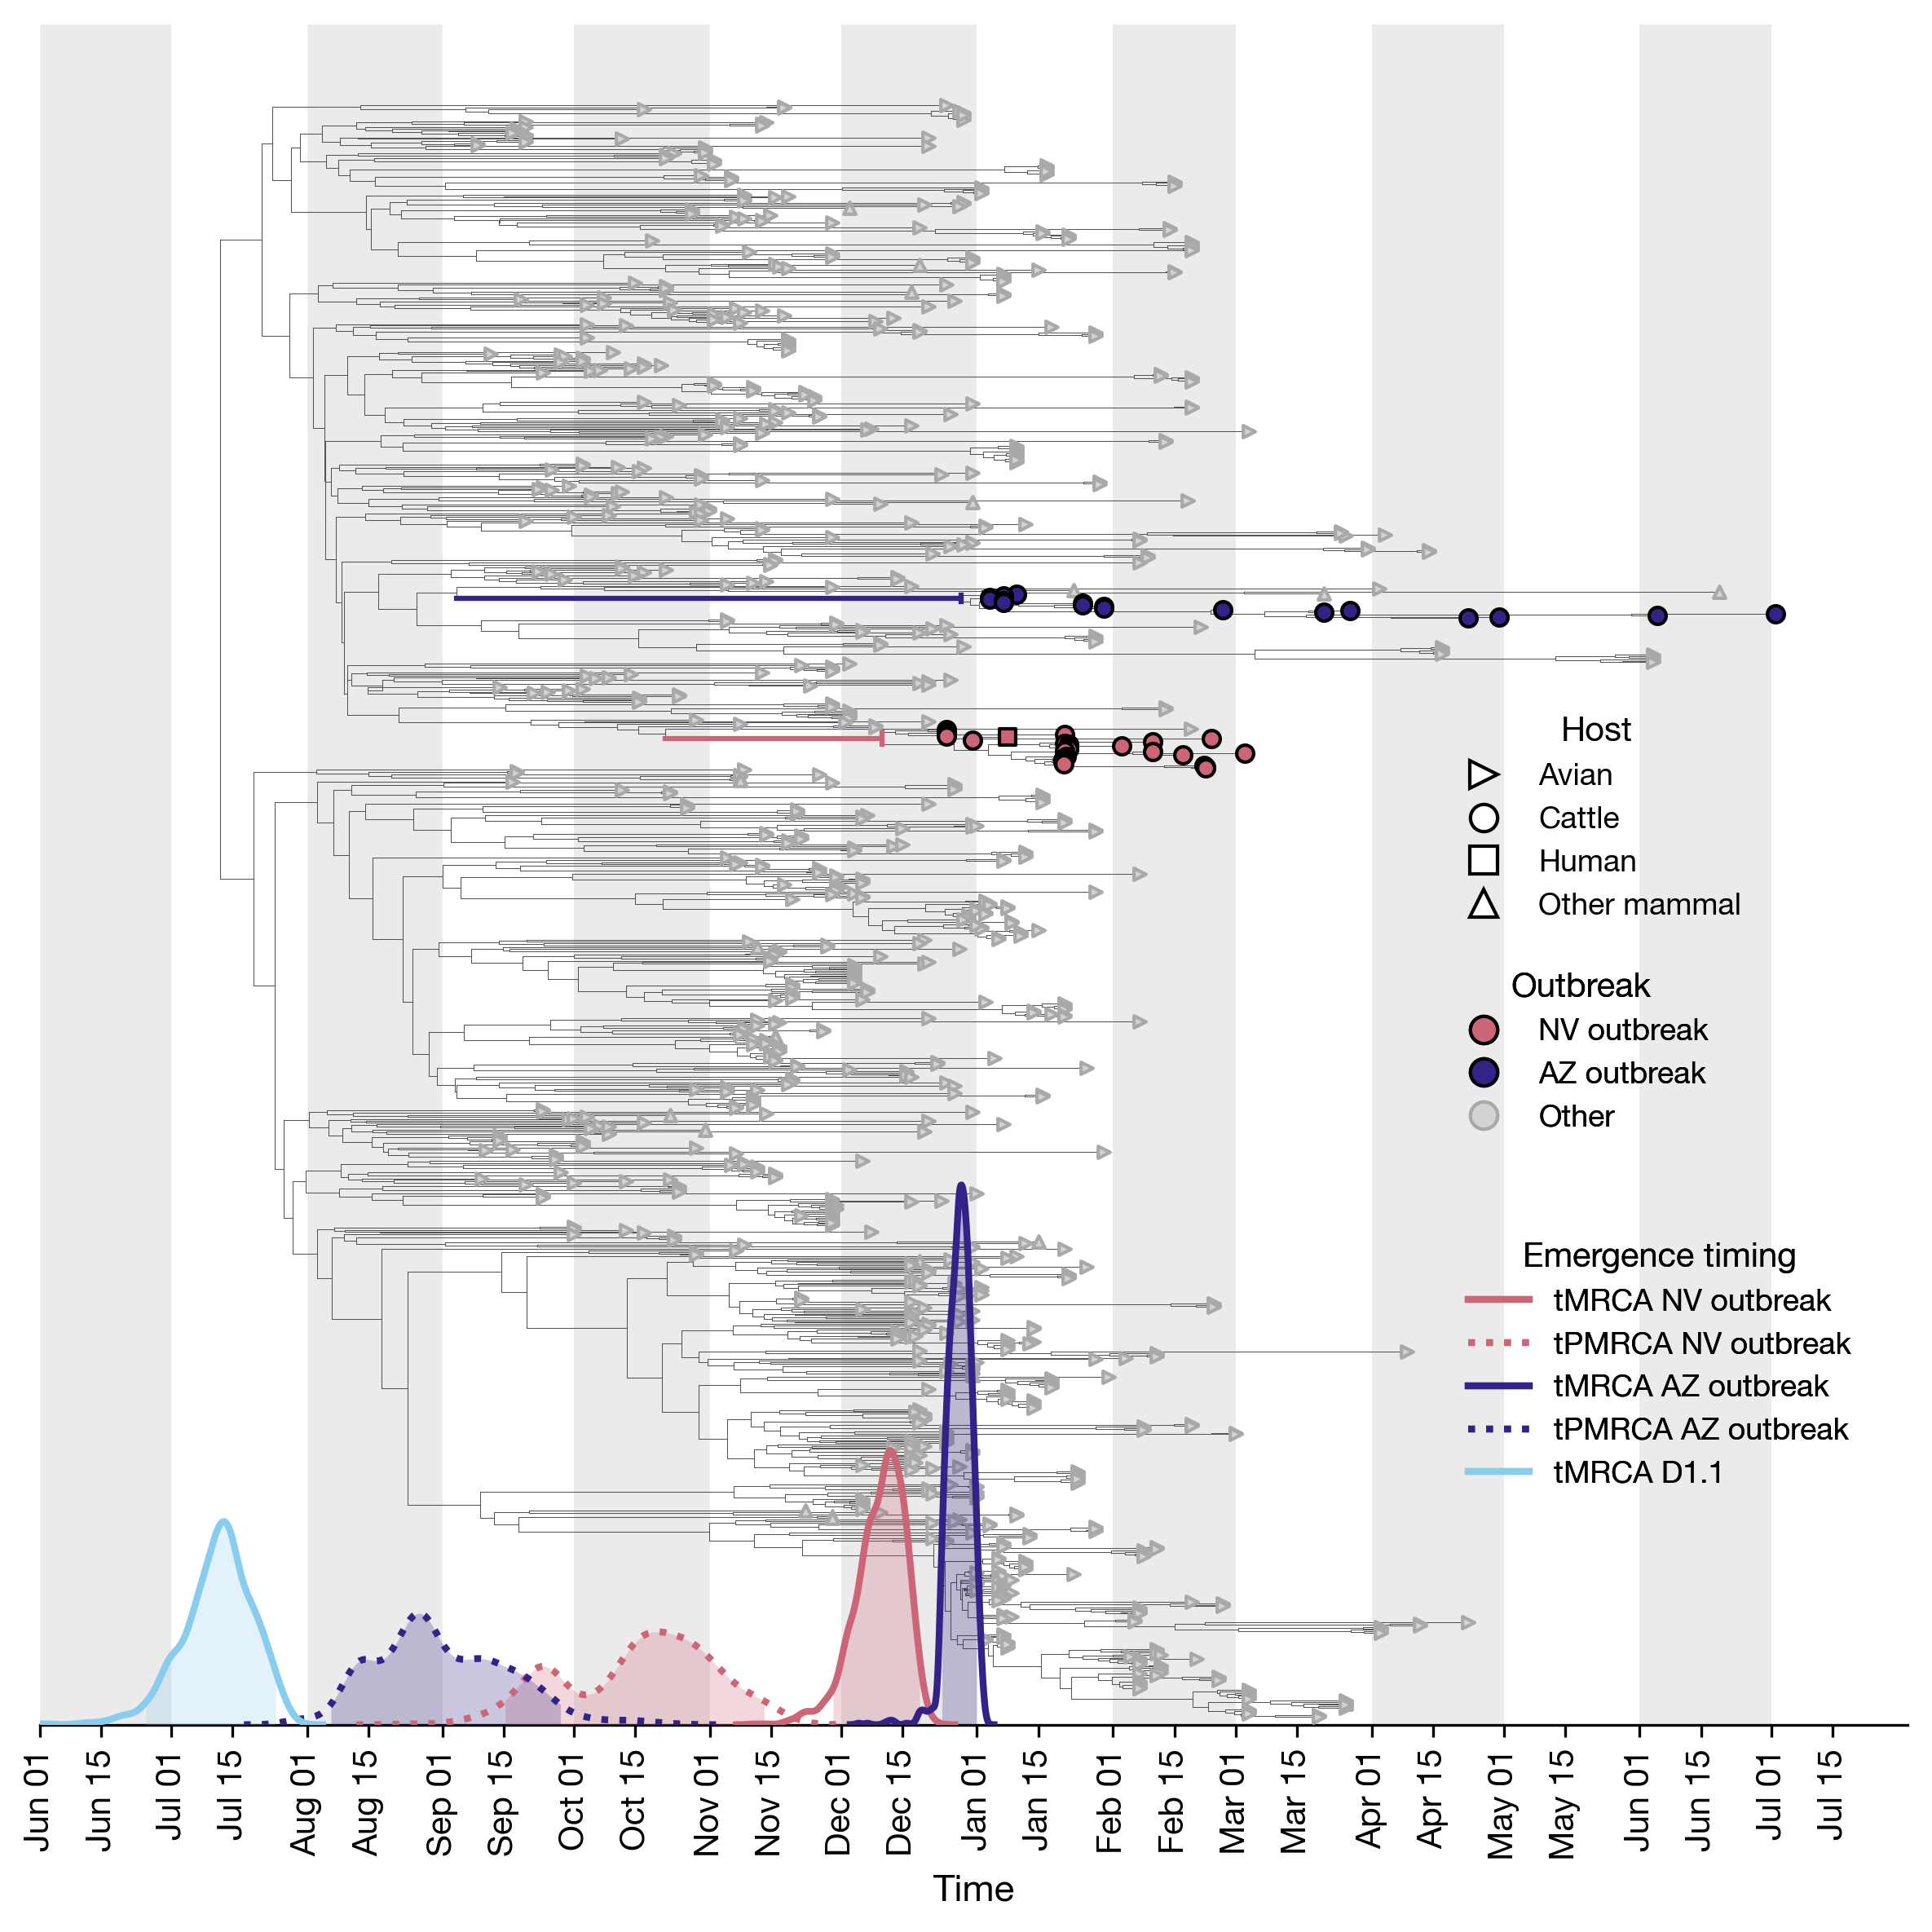

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import tol_colors as tc
import baltic as bt  # adjust import name if needed


def assign_absolute_times_from_root_heights(tree):
    """
    Given a baltic tree whose .height is measured from the root,
    infer a linear mapping

        absoluteTime = a + b * height

    using tip heights vs tip sampling dates from tip labels.

    Tip labels must contain at least one 'YYYY-MM-DD' token.
    """

    tip_heights = []
    tip_dates = []

    for tip in tree.getExternal():
        parts = tip.name.split('|')
        date_str = None
        for p in parts:
            # simple YYYY-MM-DD heuristic
            if len(p) == 10 and p[4] == '-' and p[7] == '-':
                date_str = p
                break

        if date_str is None:
            continue

        try:
            dec_date = bt.decimalDate(date_str)
        except Exception:
            continue

        h = getattr(tip, "height", None)
        if h is None:
            continue

        tip_heights.append(float(h))
        tip_dates.append(float(dec_date))

    if len(tip_heights) < 2:
        raise ValueError(
            "Not enough tips with parsable dates to fit height→time mapping."
        )

    tip_heights = np.array(tip_heights)
    tip_dates = np.array(tip_dates)

    # Fit linear mapping: date ≈ a + b * height
    b, a = np.polyfit(tip_heights, tip_dates, 1)  # slope b, intercept a

    # Assign absoluteTime to all nodes
    for node in tree.Objects:
        h = getattr(node, "height", None)
        if h is None:
            raise ValueError("Node missing .height — cannot assign absoluteTime.")
        node.absoluteTime = a + b * float(h)

    # Store mostRecent as max tip absoluteTime
    tree.mostRecent = max(
        node.absoluteTime for node in tree.getExternal()
        if getattr(node, "absoluteTime", None) is not None
    )

    return tree


def get_mrca(tree, taxa: List[str]):
    """
    Given a baltic tree and a list of tip names (taxa),
    return the MRCA node of those taxa, or None if not found.
    """
    mrca_node = None

    for k in tree.getInternal(): ## iterate over nodes
        all_children = list(k.leaves) ## fetch all descendant tips of node
        all_children_tipMap_names = [tree.tipMap[child] for child in all_children]

        if all(c in all_children_tipMap_names for c in taxa) or all(c in all_children for c in taxa):
            if mrca_node is None or k.absoluteTime > mrca_node.absoluteTime:
                mrca_node = k

    return mrca_node


def get_all_descendant_nodes(tree, node):
    """
    Given a baltic tree and a node, return all descendant nodes of that node.
    """
    descendants = []

    def _traverse(n):
        for child in n.children:
            descendants.append(child)
            
            if not child.is_leaf():
                _traverse(child)

    _traverse(node)
    return descendants


def plot_d11_tree_with_kdes(tt_sub_path, tmrcas_df, figsize=(12, 8)):
    """
    B3.13-focused tree with KDEs:

      Tree:
        - x-axis = calendar time (decimal years; from absoluteTime)
        - color = host (avian, cattle, human, other_mammal)
        - fill vs hollow = lineage (B3.13 vs non-B3.13)

      KDEs (twin y-axis, same x scale):
        - tmrca_outbreak, tpmrca_outbreak (same color, solid/dashed)
        - tmrca_b313,   tpmrca_b313    (same color, solid/dashed)
    """

    # ---------- colors & markers ----------
    cset = tc.tol_cset('muted')

    host_colors = {
        'avian':        cset[0],
        'cattle':       cset[1],
        'human':        cset[2],
        'other_mammal': cset[3],
    }

    host_markers = {
        'avian': '>',
        'cattle': 'o',
        'human': 's',
        'other_mammal': '^',
    }

    # KDE colors
    col_outbreak = cset[1]      # outbreak TMRCA curves
    col_b313_tmrca = cset[4]    # B3.13 TMRCA curves

    def parse_host_and_clade(name: str):
        """
        Assumes tip name ends with ...|HOST|CLADE,
        e.g. ...|avian|B3.13 or ...|cattle|other.
        Returns (host, clade).
        """
        parts = name.split('|')
        if len(parts) < 2:
            return 'other_mammal', 'other'
        host = parts[-2].lower()
        clade = parts[-1]

        if host not in ['avian', 'cattle', 'human', 'other_mammal']:
            if 'avian' in host:
                host = 'avian'
            elif 'cattle' in host:
                host = 'cattle'
            elif 'human' in host:
                host = 'human'
            else:
                host = 'other_mammal'

        return host, clade

    # ---------- load tree & assign absolute times ----------
    tree = bt.loadNexus(tt_sub_path)
    # assign_absolute_times_from_root_heights(tree)

    x_attr = lambda k: k.absoluteTime
    
    # # ---------- highlight focal nodes ----------
    # outbreak 1 & 2 MRCA nodes
    mrca_ts1 = get_mrca(tree, [k.name for k in tree.getExternal() if k.name in taxon_set_1 or "'" +k.name+"'" in taxon_set_1])
    mrca_ts2 = get_mrca(tree, [k.name for k in tree.getExternal() if k.name in taxon_set_2 or "'" +k.name+"'" in taxon_set_2])

    # get all descendant nodes of mrca_ts1 and mrca_ts2
    descendants_ts1 = get_all_descendant_nodes(tree, mrca_ts1)
    descendants_ts2 = get_all_descendant_nodes(tree, mrca_ts2)
    
    focal_path = descendants_ts1 + descendants_ts2 # + [mrca_ts1, mrca_ts2]
    pad_nodes = {k: 2 if k.is_node() and len(k.leaves) == 4 else (2 if k.is_leaf() else 1) for k in focal_path}
    # tree.drawTree(pad_nodes=pad_nodes)
    
    

    # ---------- figure & main axis ----------
    fig, ax = plt.subplots(figsize=figsize, dpi=300)

    # backbone tree
    tree.plotTree(ax, x_attr=x_attr, width=.25, colour='#555555')
    
    # colored clades
    # tree.plotTree(ax, x_attr=x_attr, width=.5, colour=cset[0], target=lambda k: k in descendants_ts1 + [mrca_ts1])
    # tree.plotTree(ax, x_attr=x_attr, width=.5, colour=cset[1], target=lambda k: k in descendants_ts2 + [mrca_ts2])
    
    tree.plotTree(ax, x_attr=x_attr, width=1.5, colour=cset[0], target=lambda k: k in [mrca_ts1])
    tree.plotTree(ax, x_attr=x_attr, width=1.5, colour=cset[1], target=lambda k: k in [mrca_ts2])
    
    # ---------- tips ----------
    for tip in tree.getExternal():
        host, clade = parse_host_and_clade(tip.name)
        marker = host_markers.get(host, 'o')

        # outbreak color
        if tip.name in taxon_set_1 or ("'" + tip.name + "'") in taxon_set_1:
            color = cset[0]   # Outbreak 1
        elif tip.name in taxon_set_2 or ("'" + tip.name + "'") in taxon_set_2:
            color = cset[1]   # Outbreak 2
        else:
            color = 'lightgrey'  # other / background

        x = x_attr(tip)
        y = tip.y
        s = 25

        if (
            tip.name in taxon_set_1 or tip.name in taxon_set_2 or
            ("'" + tip.name + "'") in taxon_set_1 or ("'" + tip.name + "'") in taxon_set_2
        ):
            # B3.13 (highlighted)
            face = color
            edge = 'k'
            lw = 1.0
            zorder = 20
        else:
            # non-B3.13
            face = color
            edge = 'darkgrey'
            lw = 1.0
            s /= 2
            zorder = 10

        ax.scatter(
            x, y,
            s=s,
            facecolor=face,
            edgecolor=edge,
            linewidth=lw,
            marker=marker,
            zorder=zorder,
        )
        
    # set y-limits to fit tree
    ymin, ymax = ax.get_ylim()
    if ymin < 0:
        # Crop off empty negative space so tree + vlines sit on the bottom
        ax.set_ylim(-5, ymax)

    # ---------- legends: host (shape) + outbreak (color) ----------
    # Host legend: shape only (no color encoding)
    host_legend_handles = [
        Line2D(
            [0], [0],
            marker=host_markers[h],
            color='none',
            markerfacecolor='white',
            markeredgecolor='black',
            markersize=8,
            label=h.replace('_', ' ').capitalize(),
        )
        for h in ['avian', 'cattle', 'human', 'other_mammal']
    ]
    legend_host = ax.legend(
        handles=host_legend_handles,
        title='Host',
        frameon=False,
        loc='upper left',
        bbox_to_anchor=(.75, 0.6),
        fontsize=9,
        title_fontsize=10,
        borderaxespad=0.0,
    )
    ax.add_artist(legend_host)

    # Outbreak legend: color only
    outbreak_legend_handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor=cset[0],
            markeredgecolor='black',
            markersize=8,
            label='NV outbreak',
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor=cset[1],
            markeredgecolor='black',
            markersize=8,
            label='AZ outbreak',
        ),
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor='lightgrey',
            markeredgecolor='darkgrey',
            markersize=8,
            label='Other',
        ),
    ]
    legend_outbreak = ax.legend(
        handles=outbreak_legend_handles,
        title='Outbreak',
        frameon=False,
        loc='upper left',
        bbox_to_anchor=(.75, 0.45),
        fontsize=9,
        title_fontsize=10,
        borderaxespad=0.0,
    )
    ax.add_artist(legend_outbreak)

    
    # ---------- KDEs on twin axis ----------
    twin_ax = ax.twinx()

    def kde_if_valid(col, color, linestyle, label):
        if col in tmrcas_df.columns:
            vals = tmrcas_df[col].dropna().values
            if len(vals) > 1 and vals.min() != vals.max():
                # 95% HPD (alpha = 0.05)
                hpd_low, hpd_high = hpd_single(vals, alpha=0.05)
                hpd_vals = vals[(vals >= hpd_low) & (vals <= hpd_high)]
                
                # Plot KDE line
                sns.kdeplot(
                    x=vals,
                    ax=twin_ax,
                    color=color,
                    linewidth=2,
                    linestyle=linestyle,
                    label=label,
                    # cut=0,
                )

                # Get the line that was just added
                kde_line = twin_ax.lines[-1]
                x_data = kde_line.get_xdata()
                y_data = kde_line.get_ydata()

                # Mask points within the HPD interval
                mask = (x_data >= hpd_low) & (x_data <= hpd_high)
                if mask.any():
                    x_hpd = x_data[mask]
                    y_hpd = y_data[mask]

                    # Fill HPD region
                    twin_ax.fill_between(
                        x_hpd,
                        0,
                        y_hpd,
                        color=color,
                        alpha=0.25,
                        linewidth=0,
                    )
    
    # Outbreak 1: solid = tmrca, dashed = tpmrca, but only ONE legend entry
    kde_if_valid('tmrca_ts1',  cset[0], '-',  'tMRCA NV outbreak')
    kde_if_valid('tpmrca_ts1', cset[0], ':', 'tPMRCA NV outbreak')  # no legend entry

    # Outbreak 2: same logic
    kde_if_valid('tmrca_ts2',  cset[1], '-',  'tMRCA AZ outbreak')
    kde_if_valid('tpmrca_ts2', cset[1], ':', 'tPMRCA AZ outbreak')  # no legend entry
    
    # tMRCA
    kde_if_valid('tmrca', cset[4], '-', 'tMRCA D1.1')


    # Compress KDE y-axis & hide it
    if twin_ax.lines:
        ymax = twin_ax.get_ylim()[1]
        twin_ax.set_ylim(0, ymax * 3)
    twin_ax.set_yticks([])
    twin_ax.set_yticklabels([])
    twin_ax.set_ylabel(None)
    for loc in twin_ax.spines:
        twin_ax.spines[loc].set_visible(False)

    # KDE legend on right
    kde_handles, kde_labels = twin_ax.get_legend_handles_labels()
    if kde_handles:
        legend_kde = twin_ax.legend(
            kde_handles,
            kde_labels,
            frameon=False,
            loc='upper left',
            bbox_to_anchor=(0.75, 0.3),
            fontsize=9,
            title='Emergence timing',
            title_fontsize=10,
        )
        
    twin_ax.add_artist(legend_kde)

    # ---------- x-axis as calendar time ----------
    month_timeline = ['2024-%02d-01' % m for m in range(6, 13)]
    month_timeline += ['2025-%02d-01' % m for m in range(1, 8)]

    every = 14
    end = 28
    calendar_timeline = []
    calendar_timeline += ['2024-06-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-07-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-08-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-09-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-10-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-11-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2024-12-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2025-01-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2025-02-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2025-03-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2025-04-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2025-05-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2025-06-%02d' % d for d in range(1, end, every)]
    calendar_timeline += ['2025-07-%02d' % d for d in range(1, end, every)]

    ax.set_xticks([bt.decimalDate(d) for d in calendar_timeline])
    ax.set_xticklabels(
        [bt.convertDate(d, '%Y-%m-%d', '%b %d') for d in calendar_timeline],
        rotation=90,
    )

    # alternating month shading
    for i in range(len(month_timeline) - 1):
        if i % 2 == 0:
            ax.axvspan(
                bt.decimalDate(month_timeline[i]),
                bt.decimalDate(month_timeline[i + 1]),
                fc='k',
                ec='none',
                alpha=0.08,
                zorder=0,
            )

    # x-range: outbreak window (tweak if needed)
    ax.set_xlim(
        bt.decimalDate('2024-06-01'),
        bt.decimalDate('2025-08-01'),
    )

    # ---------- cosmetics ----------
    ax.set_yticks([])
    ax.set_yticklabels([])

    for loc in ax.spines:
        if loc != 'bottom':
            ax.spines[loc].set_visible(False)

    ax.set_xlabel("Time", fontsize=11)

    fig.tight_layout()
    return fig, ax, twin_ax


# load json
with open('D1.1_SEP19.UCLD.combined.burninRemoved.resampled.trees.tmrcas_df.json', 'r') as f:
    d11_tmrcas_df_json = json.load(f)
# convert back to dataframe
d11_tmrcas_df = pd.DataFrame(d11_tmrcas_df_json)

d11_tree_path = '../analysis/d11/beast/sep19/noRC/D1.1_SEP19.UCLD.combined.burninRemoved.resampled.hipstr.tree'
fig, ax, twin_ax = plot_d11_tree_with_kdes(d11_tree_path, d11_tmrcas_df, figsize=(8, 8))
plt.show()


In [21]:
for col in d11_tmrcas_df.columns:
    median = d11_tmrcas_df[col].median()
    hpd_low, hpd_high = hpd_single(d11_tmrcas_df[col].dropna().values, alpha=0.05)
    print(f"{col}: \n\tmedian={median:.3f}\n\t95% HPD=({hpd_low:.3f}, {hpd_high:.3f})\n\tmedian date={toDatestring(median)}\n\t95% HPD dates=({toDatestring(hpd_low)}, {toDatestring(hpd_high)})\n")

tmrca: 
	median=2024.527
	95% HPD=(2024.481, 2024.563)
	median date=2024-07-11
	95% HPD dates=(2024-06-25, 2024-07-24)

tmrca_ts1: 
	median=2024.943
	95% HPD=(2024.910, 2024.964)
	median date=2024-12-11
	95% HPD dates=(2024-11-28, 2024-12-18)

tpmrca_ts1: 
	median=2024.795
	95% HPD=(2024.705, 2024.869)
	median date=2024-10-17
	95% HPD dates=(2024-09-15, 2024-11-13)

tmrca_ts2: 
	median=2024.989
	95% HPD=(2024.978, 2025.000)
	median date=2024-12-27
	95% HPD dates=(2024-12-24, 2025-01-01)

tpmrca_ts2: 
	median=2024.658
	95% HPD=(2024.596, 2024.740)
	median date=2024-08-28
	95% HPD dates=(2024-08-06, 2024-09-28)

